In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="8s4OmZrnk8wBMxLkmHTl")
project = rf.workspace("neural-networks-research").project("hard-hat-detection-62dxm")
version = project.version(1)
dataset = version.download("yolov12")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 70.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hard-Hat-Detection-1 in yolov12:: 100%|██████████| 10005/10005 [00:01<00:00, 6163.51it/s]


In [2]:
!pip install ultralytics
from ultralytics import YOLO

!ls

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Hard-Hat-Detection-1  sample_data


# Cek Jumlah Perkelas

In [3]:
import os

train_path = "/content/Hard-Hat-Detection-1/train/images"
valid_path = "/content/Hard-Hat-Detection-1/valid/images"
test_path = "/content/Hard-Hat-Detection-1/test/images"

print("Train:", len(os.listdir(train_path)))
print("Valid:", len(os.listdir(valid_path)))
print("Test:", len(os.listdir(test_path)))

Train: 3500
Valid: 1000
Test: 500


Total keseluruhan data adalah 5000 dan dilakukan split sebesar 70:20:10 dengan jumlah data training sebanyak 3500, validation data sebanyak 1000, dan test sebanyak 500.

# Class Checking

In [ ]:
folders = ['/content/Hard-Hat-Detection-1/train/labels',
           '/content/Hard-Hat-Detection-1/valid/labels',
           '/content/Hard-Hat-Detection-1/test/labels']

for folder in folders:
    for filename in os.listdir(folder):
        if filename.endswith(".txt"):
            filepath = os.path.join(folder, filename)
            with open(filepath, 'r') as f:
                lines = f.readlines()

            new_lines = [line for line in lines if not line.startswith('2 ')]

            with open(filepath, 'w') as f:
                f.writelines(new_lines)

In [5]:
with open('/content/Hard-Hat-Detection-1/data.yaml', 'r') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['head', 'helmet', 'person']

roboflow:
  workspace: neural-networks-research
  project: hard-hat-detection-62dxm
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/neural-networks-research/hard-hat-detection-62dxm/dataset/1


Model memiliki 3 kelas yang akan didetect, yaitu head, helmet, dan person.
dimana head adalah kepala orang, helmet adalah pelindung yang dipakai dan person adalah keseluruhan tubuh.





# Distribusi Perkelas

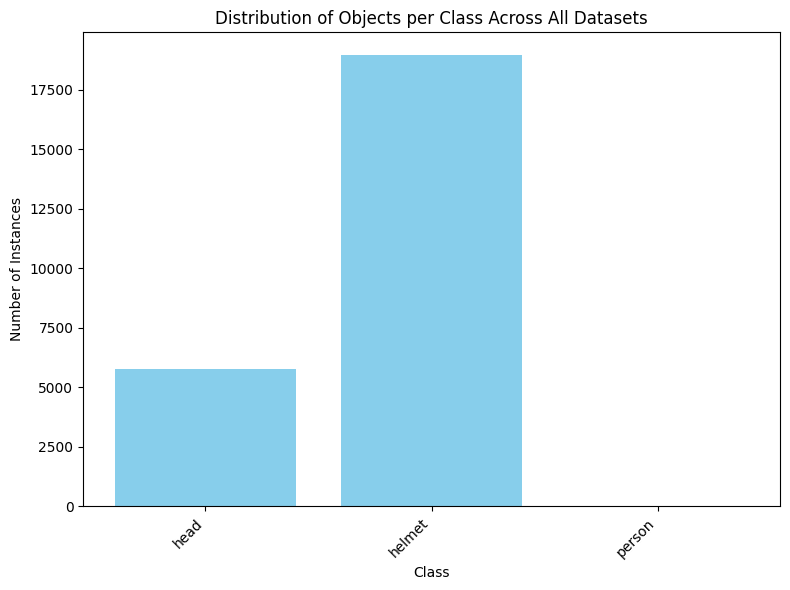

Class distribution:
- head: 5785 instances
- helmet: 18966 instances
- person: 0 instances


In [6]:
import matplotlib.pyplot as plt
import yaml
import os

data_yaml_path = '/content/Hard-Hat-Detection-1/data.yaml'
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

classes = data_config['names']
num_classes = data_config['nc']

class_counts = {i: 0 for i in range(num_classes)}

base_data_dir = '/content/Hard-Hat-Detection-1'
label_dirs = [
    os.path.join(base_data_dir, 'train', 'labels'),
    os.path.join(base_data_dir, 'valid', 'labels'),
    os.path.join(base_data_dir, 'test', 'labels')
]

for label_dir in label_dirs:
    if not os.path.exists(label_dir):
        print(f"Warning: Label directory not found: {label_dir}. Skipping.")
        continue
    for label_file_name in os.listdir(label_dir):
        if label_file_name.endswith('.txt'):
            label_file_path = os.path.join(label_dir, label_file_name)
            with open(label_file_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_id = int(parts[0])
                        if 0 <= class_id < num_classes:
                            class_counts[class_id] += 1
                        else:
                            print(f"Warning: Invalid class ID {class_id} found in {label_file_path}")

class_names = [classes[i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]

# Plot the distribution
plt.figure(figsize=(8, 6))
plt.bar(class_names, counts, color='skyblue')
plt.xlabel("Class")
plt.ylabel("Number of Instances")
plt.title("Distribution of Objects per Class Across All Datasets")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Class distribution:")
for i, name in enumerate(class_names):
    print(f"- {name}: {counts[i]} instances")

Plot ini berarti bahwa ada kelas yang imbalanced. Helmet merupakan mayoritas dengan lebih dari 17500 instances, head diantara 5000 dan 7500 dan minoritas yakni person dengan 751 instances.

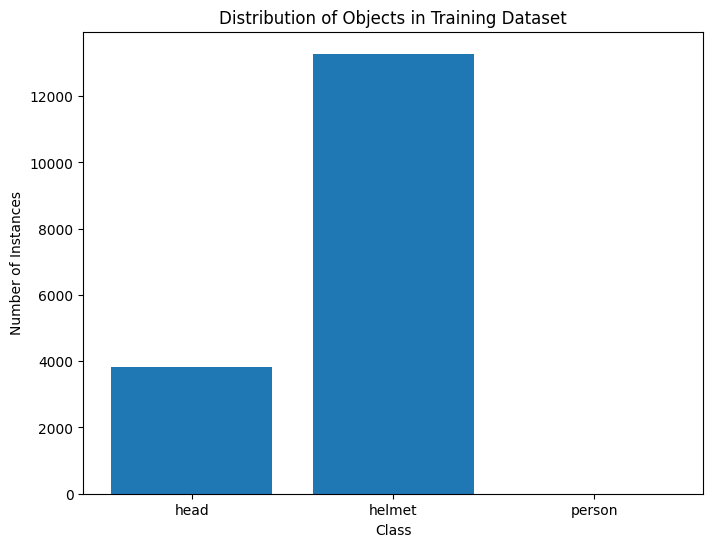

Training set distribution:
head: 3818
helmet: 13283
person: 0


In [7]:
import matplotlib.pyplot as plt
import yaml
import os

data_yaml_path = '/content/Hard-Hat-Detection-1/data.yaml'
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

classes = data_config['names']
num_classes = data_config['nc']

class_counts = {i: 0 for i in range(num_classes)}

base_data_dir = '/content/Hard-Hat-Detection-1'

# TRAIN ONLY
label_dirs = [
    os.path.join(base_data_dir, 'train', 'labels')
]

for label_dir in label_dirs:
    for label_file_name in os.listdir(label_dir):
        if label_file_name.endswith('.txt'):
            label_file_path = os.path.join(label_dir, label_file_name)
            with open(label_file_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_id = int(parts[0])
                        class_counts[class_id] += 1

class_names = [classes[i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]

plt.figure(figsize=(8,6))
plt.bar(class_names, counts)
plt.xlabel("Class")
plt.ylabel("Number of Instances")
plt.title("Distribution of Objects in Training Dataset")
plt.show()

print("Training set distribution:")
for i, name in enumerate(class_names):
    print(f"{name}: {counts[i]}")

Berdasarkan distribusi objek pada training dataset, terdapat imbalance jumlah anotasi antar kelas. Kelas helmet memiliki 13.283 , head memiliki 3.818, sedangkan person memiliki jumlah paling sedikit. Imbalance ini akan menyebabkan model lebih banyak belajar mengenali kelas mayoritas sehingga performa deteksi pada kelas person menjadi rendah.

# CHECK : image corrupt, jumlah object per-image, channel rgb,ratio

In [8]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

def advanced_eda(dataset_path, split='train'):
    image_folder = os.path.join(dataset_path, split, 'images')
    label_folder = os.path.join(dataset_path, split, 'labels')

    data_stats = []
    corrupt_files = []


    for img_name in tqdm(os.listdir(image_folder)):
        img_path = os.path.join(image_folder, img_name)
        lab_path = os.path.join(label_folder, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))

        # Cek Image Corrupt & Channel
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                channels = len(img.getbands()) # RGB = 3, Grayscale = 1, RGBA = 4

                # Cek 3 channel (RGB)
                is_rgb = (channels == 3)

                # Cek Jumlah Objek
                obj_count = 0
                if os.path.exists(lab_path):
                    with open(lab_path, 'r') as f:
                        obj_count = len(f.readlines())

                data_stats.append({
                    'file': img_name,
                    'width': width,
                    'height': height,
                    'aspect_ratio': round(width/height, 2),
                    'channels': channels,
                    'obj_count': obj_count
                })
        except Exception as e:
            corrupt_files.append(img_name)

    df = pd.DataFrame(data_stats)

    print("\n--- HASIL EDA ---")
    print(f"File Corrupt: {len(corrupt_files)}")
    print(f"Rata-rata Objek per Gambar: {df['obj_count'].mean():.2f}")
    print(f"Gambar Tanpa Objek (Background): {len(df[df['obj_count'] == 0])}")
    print(f"Min Dimension: {df['width'].min()}x{df['height'].min()}")
    print(f"Max Dimension: {df['width'].max()}x{df['height'].max()}")
    print(f"Konsistensi RGB (Gambar 3-Channel): {len(df[df['channels'] == 3])} dari {len(df)} gambar")

    extreme_ar = df[(df['aspect_ratio'] > 2) | (df['aspect_ratio'] < 0.5)]
    print(f"Gambar dengan Aspect Ratio Ekstrim: {len(extreme_ar)}")

    return df

df_eda = advanced_eda(dataset.location, 'train')


100%|██████████| 3500/3500 [00:00<00:00, 6237.48it/s]


--- HASIL EDA ---
File Corrupt: 0
Rata-rata Objek per Gambar: 4.89
Gambar Tanpa Objek (Background): 0
Min Dimension: 640x640
Max Dimension: 640x640
Konsistensi RGB (Gambar 3-Channel): 3500 dari 3500 gambar
Gambar dengan Aspect Ratio Ekstrim: 0


Berdasarkan hasil EDA, dapat diketahui bahwa tidak ada file corrupt, semua gambar berukuran sama (640x640), seluruh gambar adalah gambar berwarna standar (RGB-3 Channel). Selain ini dataset ini baik karena ada sekitar 5 objek dalam satu gambar, sehingga model mampu mendeteksi banyak objek sekaligus dalam satu gambar.


# Visualisasi Data
check label dan kualitas image

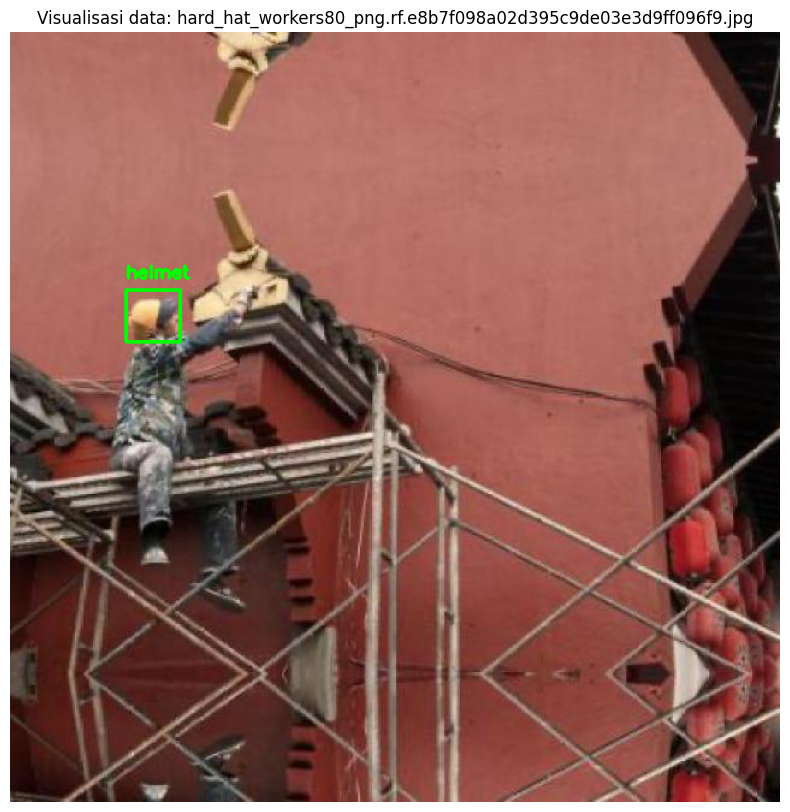

In [9]:
import cv2
import matplotlib.pyplot as plt
import random
import os

def show_sample(split='train'):
    image_dir = os.path.join(dataset.location, split, 'images')
    label_dir = os.path.join(dataset.location, split, 'labels')

    img_name = random.choice(os.listdir(image_dir))
    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(image, class_names[int(cls)], (x1, y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title(f"Visualisasi data: {img_name}")
    plt.axis('off')
    plt.show()

show_sample('train')

Anotasi dataset sudah sesuai dan bounding box sudah mengelilingi objek dengan benar yang mebuktikan bahwa format YOLO sudah sesuai untuk object detection

In [11]:
import shutil
import os

if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Training Menggunakan Model YOLO

In [12]:
model = YOLO("yolo12n.pt")

model.train(
    data="/content/Hard-Hat-Detection-1/data.yaml",
    epochs=50,
    project="/content/drive/MyDrive/YoloV12SafetyHelmet",
    name="my_helmet_model",
    imgsz=640,
    patience=10,

    batch=16,
    optimizer='AdamW',
    lr0=0.01,
    lrf=0.01,
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Hard-Hat-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=my_helmet_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mas

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e84fe2e4140>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

Dari atas ditemukan performa yang cukup solid dengan tingkat presisi sebesar 90,32%, yang berarti model sangat andal dalam meminimalisir kesalahan deteksi pada objek yang ditemukan. Sementara itu, nilai recall sebesar 84,58% mengindikasikan bahwa model mampu mendeteksi sebagian besar objek yang ada di dalam gambar dengan tingkat kehilangan (missed detection) yang relatif rendah. Dari sisi akurasi rata-rata, nilai mAP50 yang mencapai 90,22% menunjukkan performa yang sangat kuat pada ambang batas IoU standar. Namun, penurunan signifikan pada nilai mAP50-95 ke angka 55,37% memberikan catatan penting bahwa meskipun model berhasil mengenali objek dengan baik, model tersebut masih mengalami kesulitan dalam menentukan batas kotak pembatas (bounding box) yang sangat presisi secara konsisten di seluruh spektrum ambang batas IoU yang lebih ketat.

In [13]:
df = pd.read_csv('/content/drive/MyDrive/YoloV12SafetyHelmet/my_helmet_model/results.csv')
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,112.454,1.80510,1.70920,1.41544,0.47034,0.40003,0.38503,0.18529,1.88426,3.30899,1.63372,0.003318,0.003318,0.070137
1,2,201.954,1.76900,1.43318,1.45332,0.36898,0.45150,0.35275,0.17921,1.70438,2.58528,1.51019,0.006520,0.006520,0.040005
2,3,290.436,1.70908,1.32814,1.42603,0.78927,0.27765,0.35673,0.18607,1.67493,2.14087,1.47853,0.009589,0.009589,0.009742
3,4,379.119,1.67529,1.24955,1.39848,0.63052,0.51194,0.50604,0.24351,1.85319,2.14899,1.55707,0.009406,0.009406,0.009406
4,5,466.965,1.64218,1.18363,1.38747,0.80330,0.65045,0.74054,0.37642,1.68795,1.22730,1.45965,0.009208,0.009208,0.009208


## Best Epoch Berdasarkan mAP50-95, mAP50, validation box

In [14]:
best_epoch = df['metrics/mAP50-95(B)'].idxmax()
best_epoch + 1

43

In [15]:
best_epoch_map50 = df['metrics/mAP50(B)'].idxmax()
best_epoch_map50

49

In [16]:
best_epoch_val = df['val/box_loss'].idxmin()
best_epoch_val

42

# Evaluations

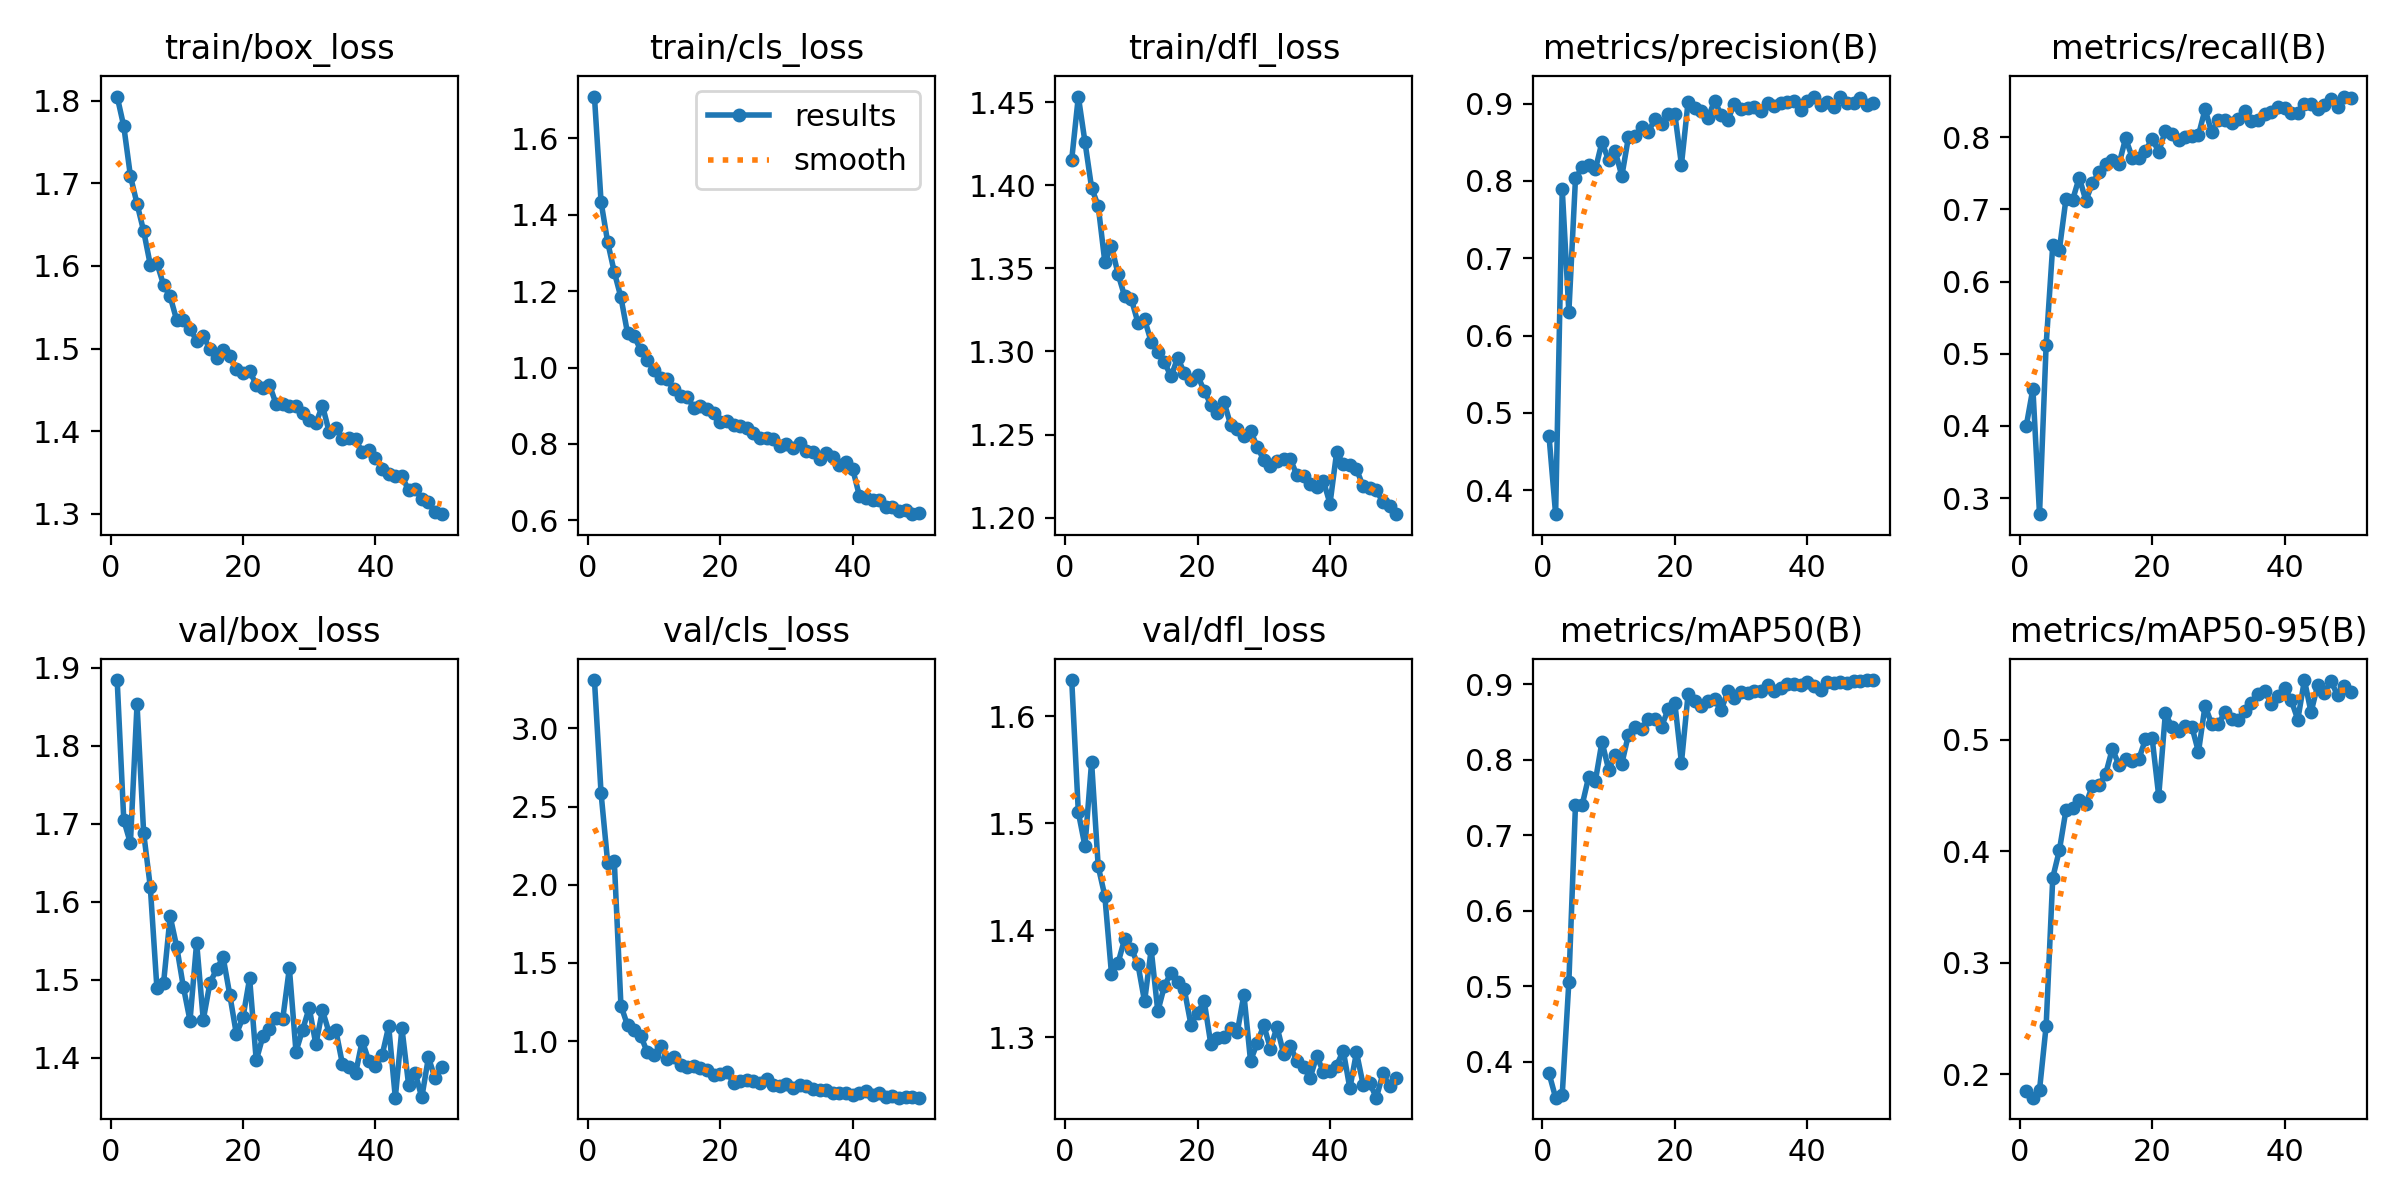

In [17]:
from IPython.display import Image
Image('/content/drive/MyDrive/YoloV12SafetyHelmet/my_helmet_model/results.png')

Berdasarkan grafik hasil pelatihan model, terlihat bahwa proses training berjalan dengan baik dan stabil. Hal ini ditunjukkan oleh penurunan yang konsisten pada seluruh nilai training loss dan validation loss, yaitu box loss, classification loss, dan distribution focal loss (DFL) dari awal hingga akhir epoch. Selain itu, tidak terlihat adanya indikasi overfitting yang signifikan karena penurunan loss pada data training diikuti oleh penurunan loss pada data validasi. Kondisi ini menunjukkan bahwa model tidak hanya mampu mempelajari pola pada data pelatihan, tetapi juga dapat melakukan generalisasi dengan baik terhadap data yang belum pernah dilihat sebelumnya.

Dari sisi performa deteksi, model mencapai nilai precision sekitar 90% dan recall sekitar 85% pada akhir pelatihan. Nilai precision yang tinggi menunjukkan bahwa sebagian besar objek yang dideteksi oleh model merupakan prediksi yang benar, sehingga jumlah false positive relatif rendah. Sementara itu, nilai recall yang sedikit lebih rendah mengindikasikan bahwa masih terdapat beberapa objek yang belum berhasil terdeteksi oleh model. Meskipun demikian, kedua metrik tersebut menunjukkan performa deteksi yang sudah cukup baik dan seimbang.

Performa keseluruhan model juga tercermin dari nilai mAP50 yang mencapai sekitar 90%, yang menunjukkan kemampuan deteksi objek yang sangat baik pada ambang IoU 0,5. Namun, nilai mAP50-95 hanya mencapai sekitar 55%, sehingga terdapat selisih yang cukup besar dibandingkan mAP50. Hal ini mengindikasikan bahwa meskipun model mampu mengenali keberadaan objek dengan baik, ketepatan posisi dan ukuran bounding box masih dapat ditingkatkan. Dengan kata lain, model sudah cukup akurat dalam menemukan objek, tetapi presisi lokalisasi objek pada berbagai tingkat IoU masih belum optimal.

### test

In [ ]:
print(model.names)

{0: 'head', 1: 'helmet', 2: 'person'}


In [ ]:
import os
from ultralytics import YOLO

model_path = '/content/drive/MyDrive/YoloV12SafetyHelmet/my_helmet_model/weights/best.pt'
model = YOLO(model_path)

model.val(
    data='/content/Hard-Hat-Detection-1/data.yaml',
    split='test',
    project='/content/evaluations',
    name='test_eval_v1',
    classes=[0, 1],
    exist_ok=True
)

print(os.listdir('/content/evaluations/test_eval_v1'))

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1388.2±717.1 MB/s, size: 50.1 KB)
val: Scanning /content/Hard-Hat-Detection-1/test/labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 2.1Kit/s 0.2s
val: New cache created: /content/Hard-Hat-Detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 4.2it/s 7.7s
                   all        500       2621      0.933      0.851       0.92      0.567
                  head         99        764      0.933       0.84      0.913      0.555
                helmet        446       1857      0.934      0.863      0.928      0.579
Speed: 1.7ms preprocess, 6.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/evaluations/test_eval_v1
['BoxPR_curve

Model deteksi objek tersebut menunjukkan kinerja yang sangat baik secara keseluruhan dengan nilai *Precision* (Box(P)) mencapai 0,933 dan *mAP50* sebesar 0,92 untuk 500 gambar dengan 2621 instansi. Jika dilihat berdasarkan kelas, performa pada deteksi "helmet" sedikit lebih unggul dibandingkan dengan "head", di mana "helmet" mencatatkan nilai *Precision* 0,934, *Recall* 0,863, dan *mAP50-95* 0,579. Sementara itu, kelas "head" memiliki nilai *Precision* 0,933, *Recall* 0,84, dan *mAP50-95* 0,555. Secara umum, model ini menunjukkan tingkat kepercayaan yang tinggi dan kemampuan deteksi yang stabil baik untuk objek kepala maupun helm.

### Confusion Matrix Test

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

path_to_matrix = '/content/evaluations/test_eval_v1_filtered/confusion_matrix.png'

if os.path.exists(path_to_matrix):
    img = mpimg.imread(path_to_matrix)
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print(f"File tidak ditemukan di: {path_to_matrix}")
    print("Isi folder evaluasi:", os.listdir('/content/evaluations/test_eval_v1/'))

File tidak ditemukan di: /content/evaluations/test_eval_v1_filtered/confusion_matrix.png
Isi folder evaluasi: ['BoxPR_curve.png', 'val_batch2_labels.jpg', 'val_batch0_labels.jpg', 'confusion_matrix.png', 'BoxP_curve.png', 'val_batch1_labels.jpg', 'val_batch0_pred.jpg', 'confusion_matrix_normalized.png', 'BoxF1_curve.png', 'BoxR_curve.png', 'val_batch1_pred.jpg', 'val_batch2_pred.jpg']


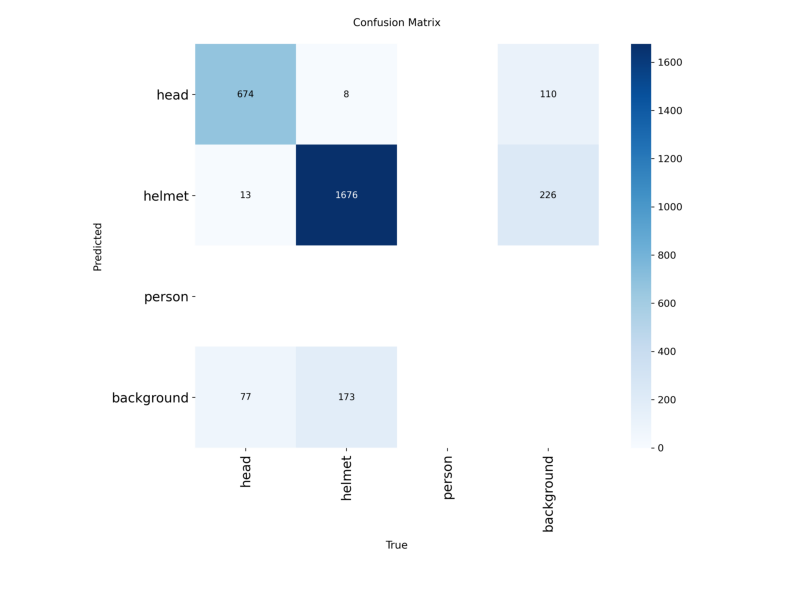

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

path_to_matrix = '/content/evaluations/test_eval_v1/confusion_matrix.png'

if os.path.exists(path_to_matrix):
    img = mpimg.imread(path_to_matrix)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print(f"File masih tidak ditemukan di: {path_to_matrix}")

Model menunjukkan performa klasifikasi yang sangat kuat, terutama dalam membedakan antara objek head dan helmet. Model berhasil mengidentifikasi dengan benar 674 instansi untuk head dan 1676 instansi untuk helmet. Meskipun demikian, terdapat sedikit kebingungan antara kedua kelas tersebut, di mana 13 instansi helmet salah diprediksi sebagai head, dan 8 instansi head salah diprediksi sebagai helmet. Selain itu, model masih mengalami tantangan dalam membedakan objek dari latar belakang, yang terlihat dari 77 kasus latar belakang yang dianggap head dan 173 kasus latar belakang yang dianggap helmet, serta adanya false negative sebanyak 110 untuk head dan 226 untuk helmet yang terklasifikasi sebagai latar belakang.

# Training and Validation Result

## Training Dataset Distribution (Ini tadi udah diatas)

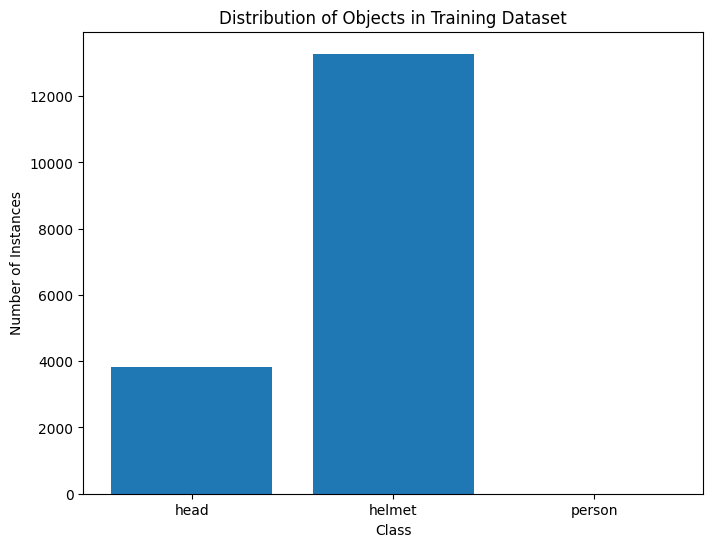

In [23]:
data_yaml_path = '/content/Hard-Hat-Detection-1/data.yaml'
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

classes = data_config['names']
num_classes = data_config['nc']

class_counts = {i: 0 for i in range(num_classes)}

label_dir = '/content/Hard-Hat-Detection-1/train/labels'

for label_file_name in os.listdir(label_dir):
    if label_file_name.endswith('.txt'):
        with open(os.path.join(label_dir, label_file_name), 'r') as f:
            for line in f:
                class_id = int(line.strip().split()[0])
                class_counts[class_id] += 1

class_names = [classes[i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]

plt.figure(figsize=(8,6))
plt.bar(class_names, counts)
plt.title("Distribution of Objects in Training Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Instances")
plt.show()

Dari sini kembali ditekankan bahwa distribusi nya sangatlah imbalanced dimana helmet mayoritas dan person adalah minoritas, dimana helmet lebih dari 10x dari kelas person.

## Training and Validation Loss Results

<Axes: >

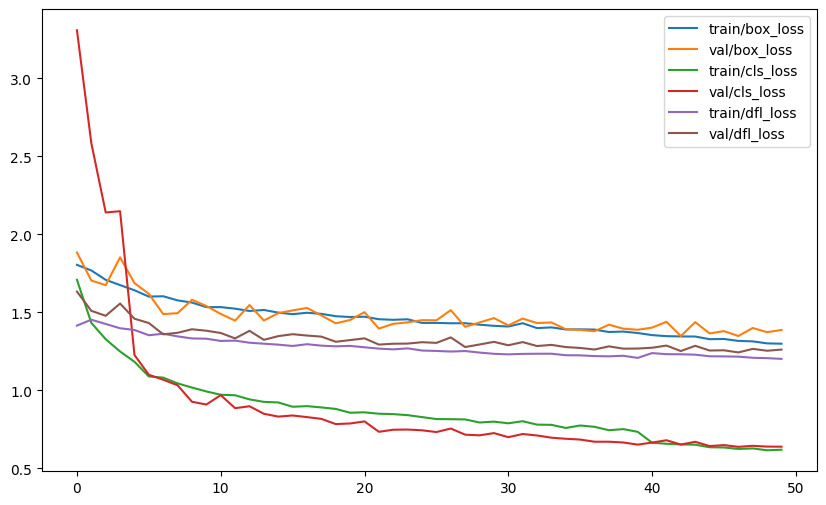

In [24]:
csv_path = '/content/drive/MyDrive/YoloV12SafetyHelmet/my_helmet_model/results.csv'

# Membaca file CSV
df = pd.read_csv(csv_path)
df[['train/box_loss','val/box_loss',
    'train/cls_loss','val/cls_loss',
    'train/dfl_loss','val/dfl_loss']].plot(figsize=(10,6))

Secara keseluruhan, model menunjukkan perilaku yang sangat positif karena semua metrik loss (yaitu box_loss, cls_loss, dan dfl_loss) terus mengalami penurunan yang konsisten, baik pada data training maupun validation. Tren konvergensi ini mengindikasikan bahwa model belajar dengan baik dan tidak terjebak dalam overfitting yang signifikan, karena validation loss tetap mengikuti tren training loss dengan selisih yang relatif kecil dan stabil. Penurunan yang cukup tajam pada cls_loss di awal iterasi menunjukkan bahwa model dengan cepat mempelajari fitur diskriminatif untuk mengklasifikasikan kelas head dan helmet dengan akurat. Selain itu, jarak yang sempit antara kurva training dan validation untuk setiap metrik menunjukkan bahwa model memiliki kemampuan generalisasi yang baik terhadap data baru yang belum pernah dilihat sebelumnya.

## Validation Performance Metrics

In [25]:
val_metrics = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'mAP@50', 'mAP@50-95'],
    'Best Value': [
        df['metrics/precision(B)'].max(),
        df['metrics/recall(B)'].max(),
        df['metrics/mAP50(B)'].max(),
        df['metrics/mAP50-95(B)'].max()
    ]
})

val_metrics

,Metric,Best Value
0,Precision,0.90914
1,Recall,0.85633
2,mAP@50,0.90529
3,mAP@50-95,0.55356


Model menunjukkan performa validasi yang cukup baik dengan mencapai nilai *Precision* sebesar 0,90914 dan *Recall* sebesar 0,85633. Selain itu, nilai *mean Average Precision* (mAP) pada ambang batas IoU 0,5 (*mAP@50*) tercatat sebesar 0,90529, yang menunjukkan kemampuan deteksi objek yang akurat pada tingkat *overlap* yang moderat. Sementara itu, nilai *mAP@50-95* sebesar 0,55356 memberikan gambaran performa model pada berbagai ambang batas IoU yang lebih ketat, yang mengindikasikan konsistensi model dalam melokalisasi objek dengan presisi yang lebih tinggi.

## Validation Precision - Recall Curve

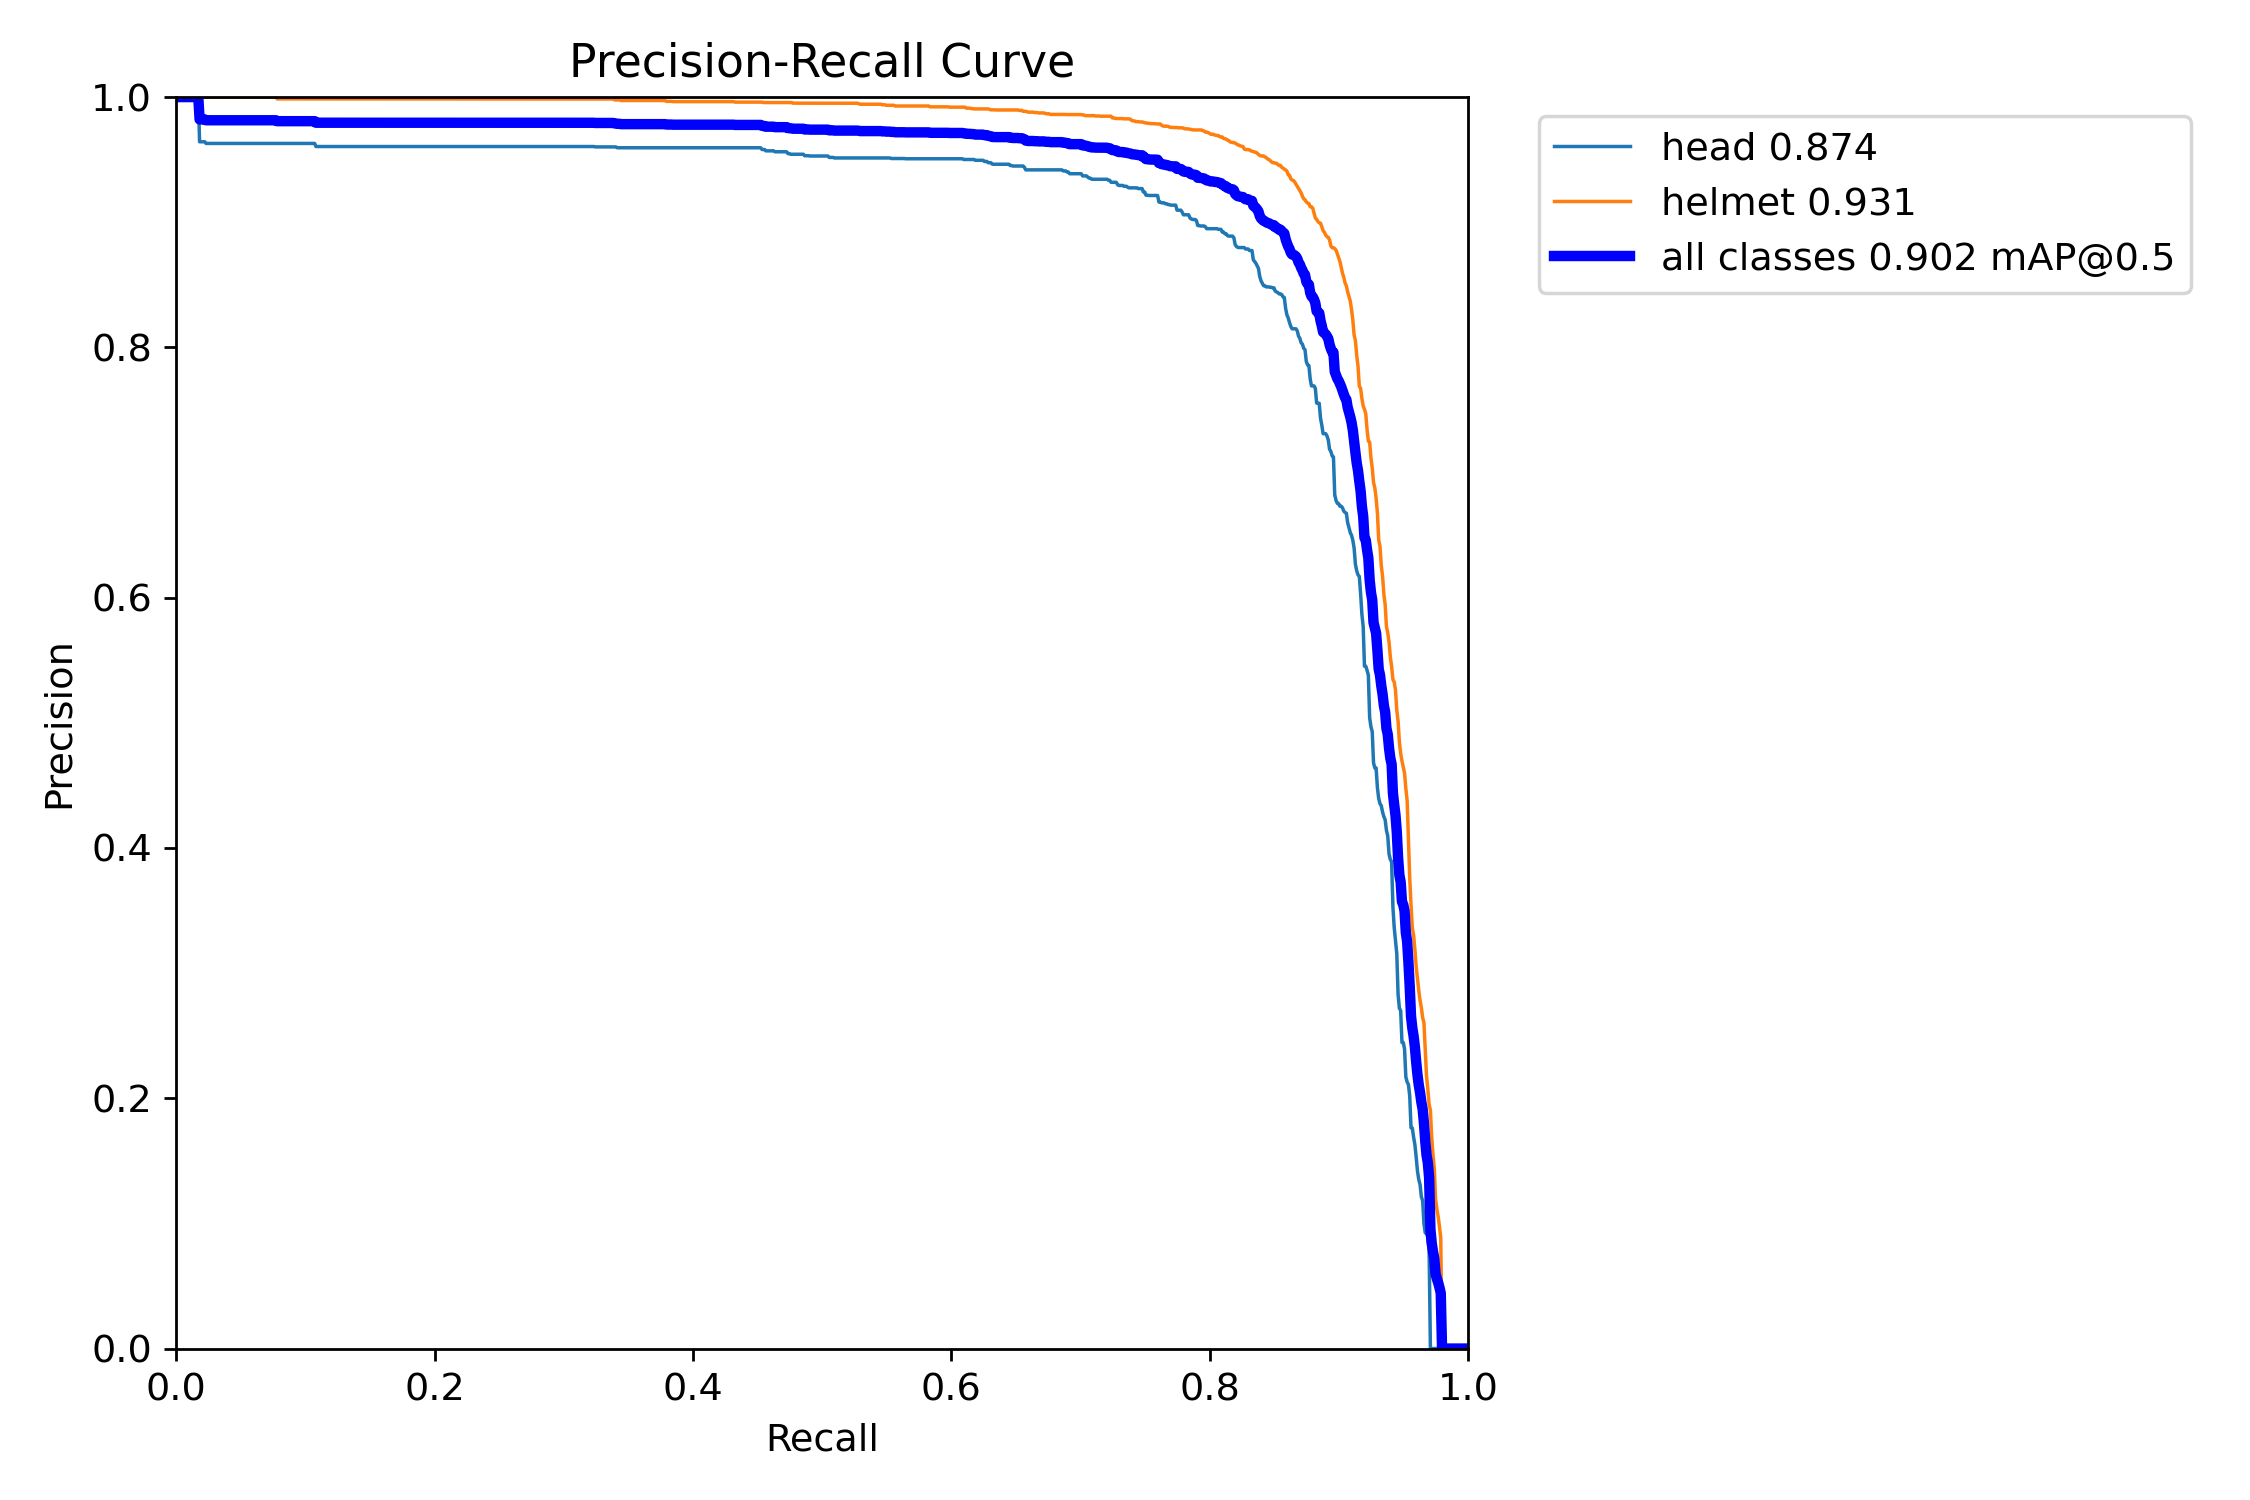

In [ ]:
path_to_pr_curve = '/content/drive/MyDrive/YoloV12SafetyHelmet/my_helmet_model/BoxPR_curve.png'
Image(filename=path_to_pr_curve)

Grafik Precision-Recall menunjukkan bahwa kelas helmet memiliki performa terbaik dengan nilai sekitar 0.950, ditandai kurva yang stabil mendekati sudut kanan atas, sehingga model sangat akurat dan konsisten dalam mendeteksi helmet. Kelas head juga memiliki performa yang baik dengan AP sekitar 0.882, meskipun precision mulai menurun saat recall meningkat tinggi, berarti  beberapa kesalahan deteksi pada kondisi tertentu. Tapi, nilai kelas person sangatlah rendah yaitu sekitar 0.033, menandakan model hampir gagal mengenali kelas tersebut karena precision dan recall sama-sama rendah. Secara keseluruhan, nilai mAP@0.5 sebesar 0.621 karena tertolong kelas helmet dan head.


## Validation F1 Curve

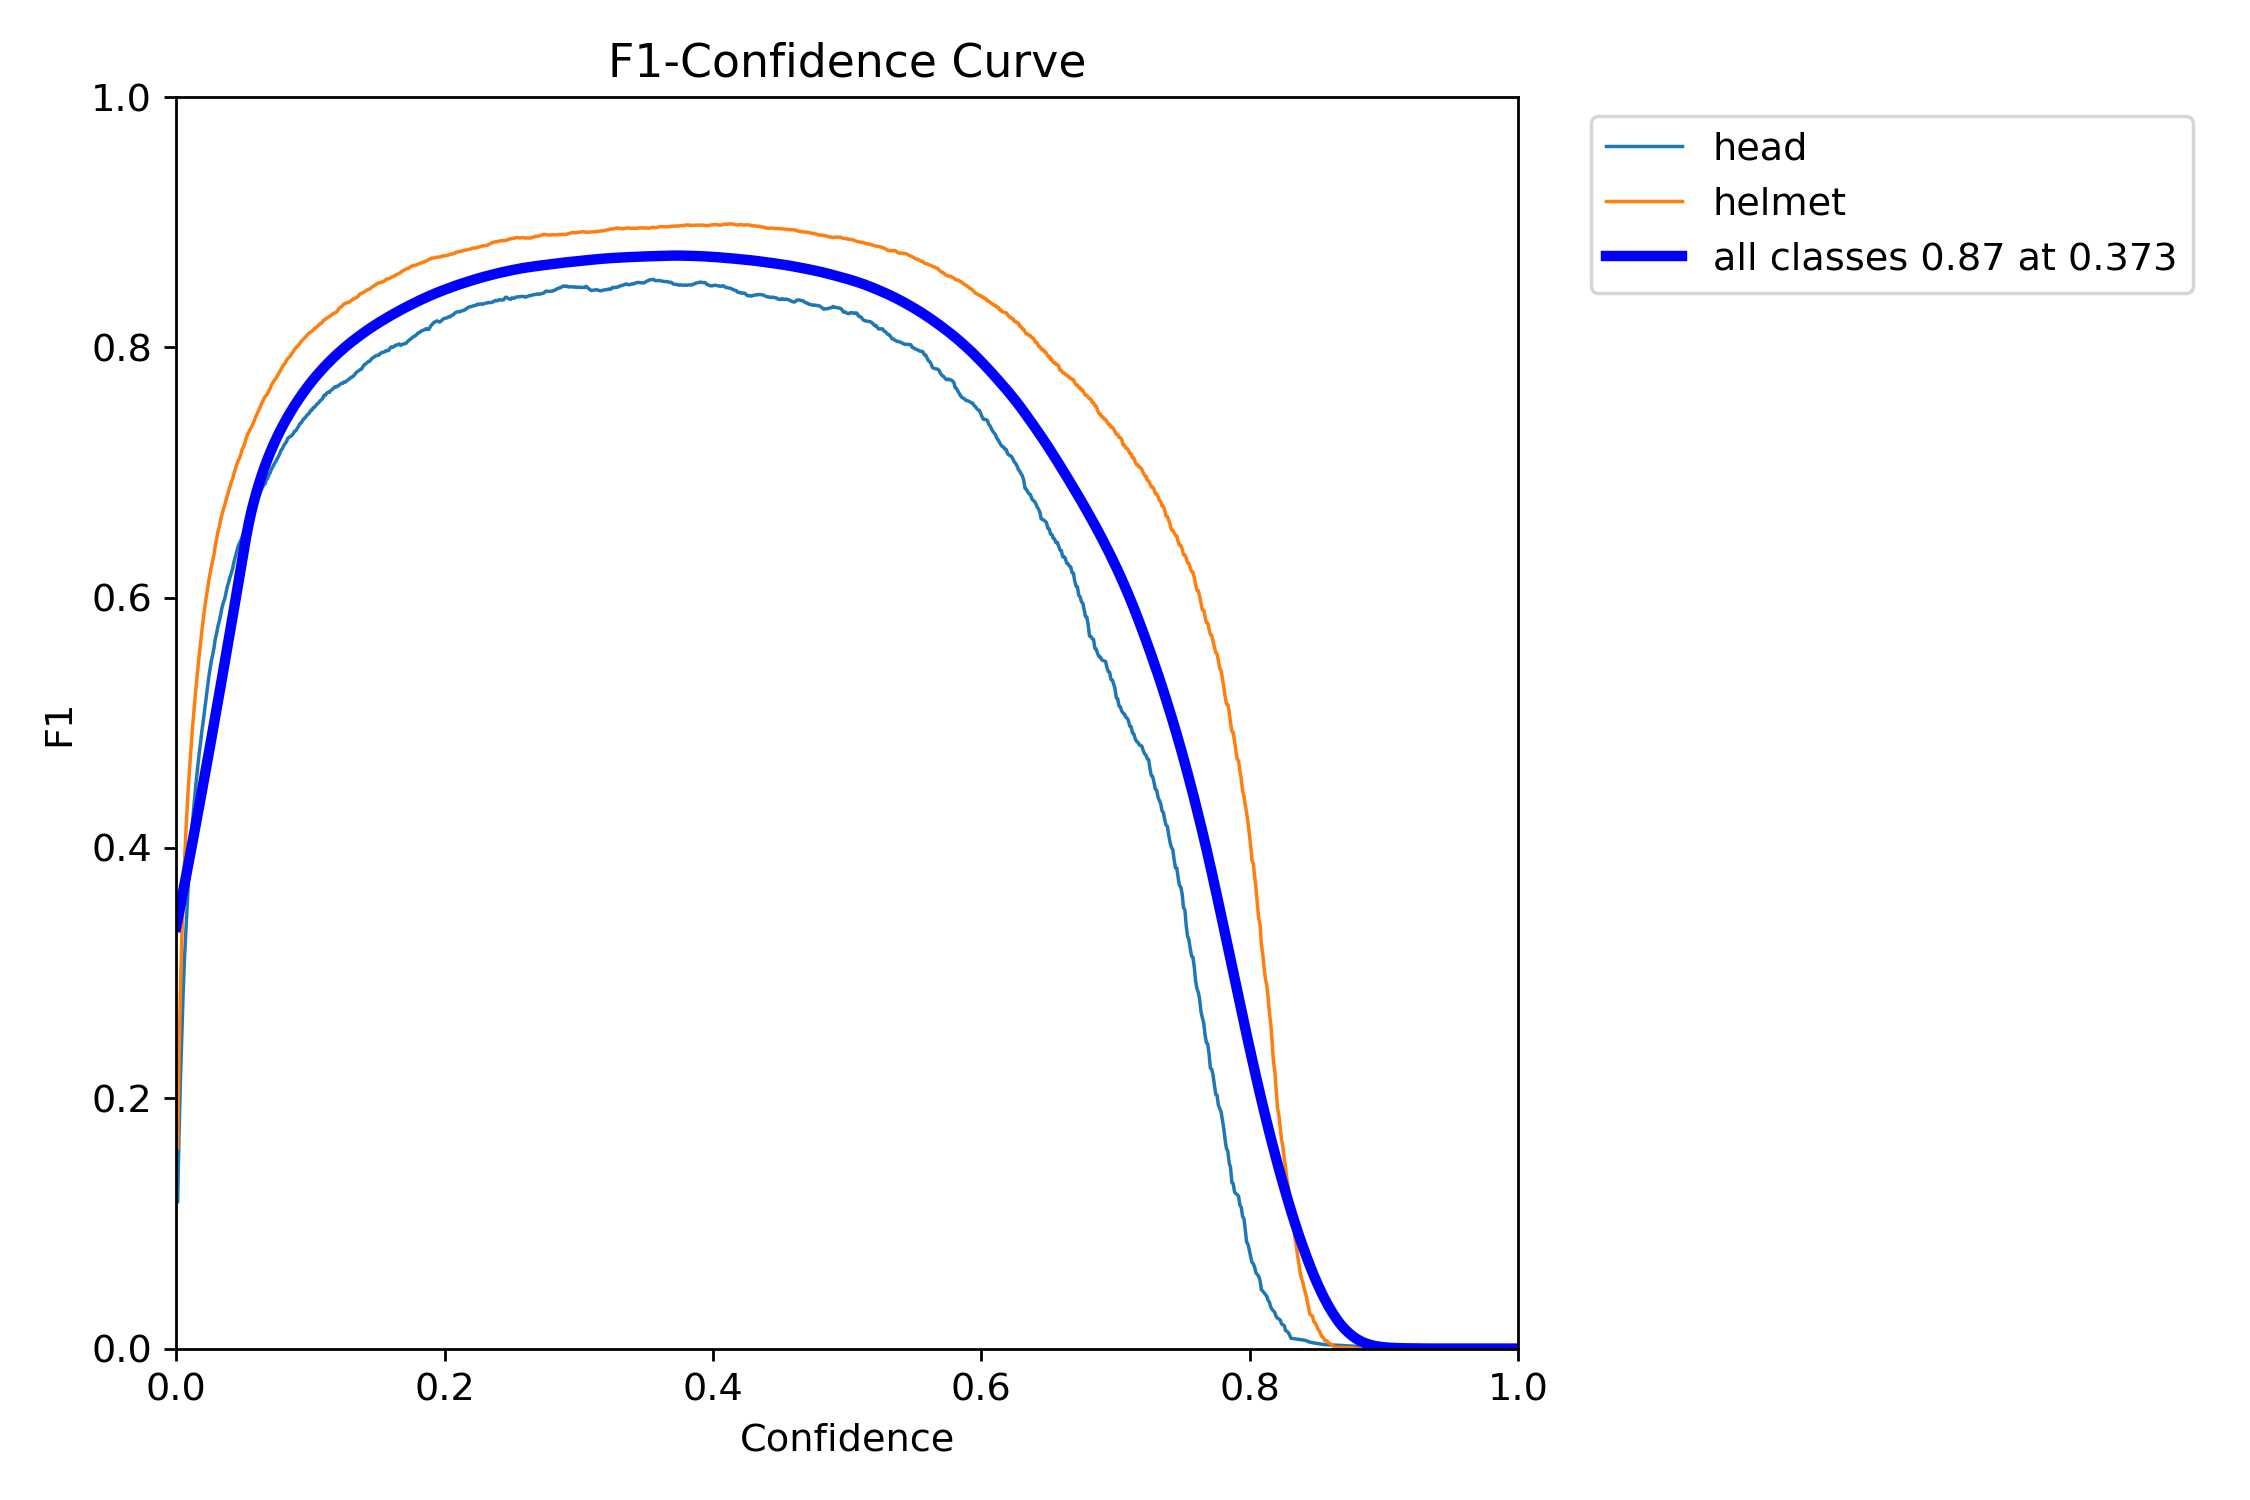

In [ ]:
path_to_f1_curve = '/content/drive/MyDrive/YoloV12SafetyHelmet/my_helmet_model/BoxF1_curve.png'
Image(filename=path_to_f1_curve)

Kurva *F1-Confidence* yang disajikan dalam gambar memberikan gambaran tentang keseimbangan optimal antara *precision* dan *recall* pada berbagai tingkat kepercayaan (*confidence threshold*). Secara keseluruhan, model mencapai nilai *F1-score* puncak sebesar 0,87 pada tingkat kepercayaan 0,373, yang menunjukkan titik keseimbangan paling efisien untuk seluruh kelas. Jika diamati per kelas, kurva "helmet" konsisten berada di atas kurva "head", yang mengindikasikan bahwa model memiliki performa yang lebih baik dalam menjaga keseimbangan *precision* dan *recall* untuk deteksi helm dibandingkan dengan deteksi kepala. Pola kurva yang melengkung dan memuncak di area tengah *confidence threshold* menunjukkan bahwa model bekerja paling optimal ketika nilai *threshold* diatur di kisaran 0,2 hingga 0,5, di mana model mampu memberikan prediksi yang cukup sensitif sekaligus memiliki tingkat kepercayaan yang memadai.

# Evaluation Results

## Test Set Overall Performance Metrics

In [ ]:
model_path = '/content/drive/MyDrive/YoloV12SafetyHelmet/my_helmet_model/weights/best.pt'
model = YOLO(model_path)

metrics = model.val(
    data='/content/Hard-Hat-Detection-1/data.yaml',
    split='test',
    project='/content/evaluations',
    name='test_eval_v1',
    exist_ok=True
)

overall_metrics = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'mAP@50', 'mAP@50-95'],
    'Value': [
        metrics.results_dict['metrics/precision(B)'], 
        metrics.results_dict['metrics/recall(B)'],    
        metrics.results_dict['metrics/mAP50(B)'],     
        metrics.results_dict['metrics/mAP50-95(B)']   
    ]
})

overall_metrics

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1697.5±292.1 MB/s, size: 49.2 KB)
val: Scanning /content/Hard-Hat-Detection-1/test/labels.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 190.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 4.3it/s 7.5s
                   all        500       2621      0.933      0.851       0.92      0.567
                  head         99        764      0.933       0.84      0.913      0.555
                helmet        446       1857      0.934      0.863      0.928      0.579
Speed: 1.9ms preprocess, 6.6ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/evaluations/test_eval_v1


,Metric,Value
0,Precision,0.933326
1,Recall,0.851498
2,mAP@50,0.920184
3,mAP@50-95,0.566737


Model menunjukkan performa yang sangat solid dengan tingkat *Precision* sebesar 0,933 dan *Recall* sebesar 0,851. Nilai *mean Average Precision* pada IoU 0,5 (*mAP@50*) mencapai angka yang impresif yaitu 0,920, yang mengindikasikan bahwa model memiliki kemampuan deteksi yang sangat akurat dalam mengenali objek pada kondisi tersebut. Sementara itu, nilai *mAP@50-95* sebesar 0,567 memberikan gambaran kinerja model pada ambang batas IoU yang lebih ketat, yang menunjukkan tingkat konsistensi dan presisi lokalisasi objek yang tetap terjaga meskipun dalam tantangan evaluasi yang lebih tinggi.

## Test Confusion Matrix

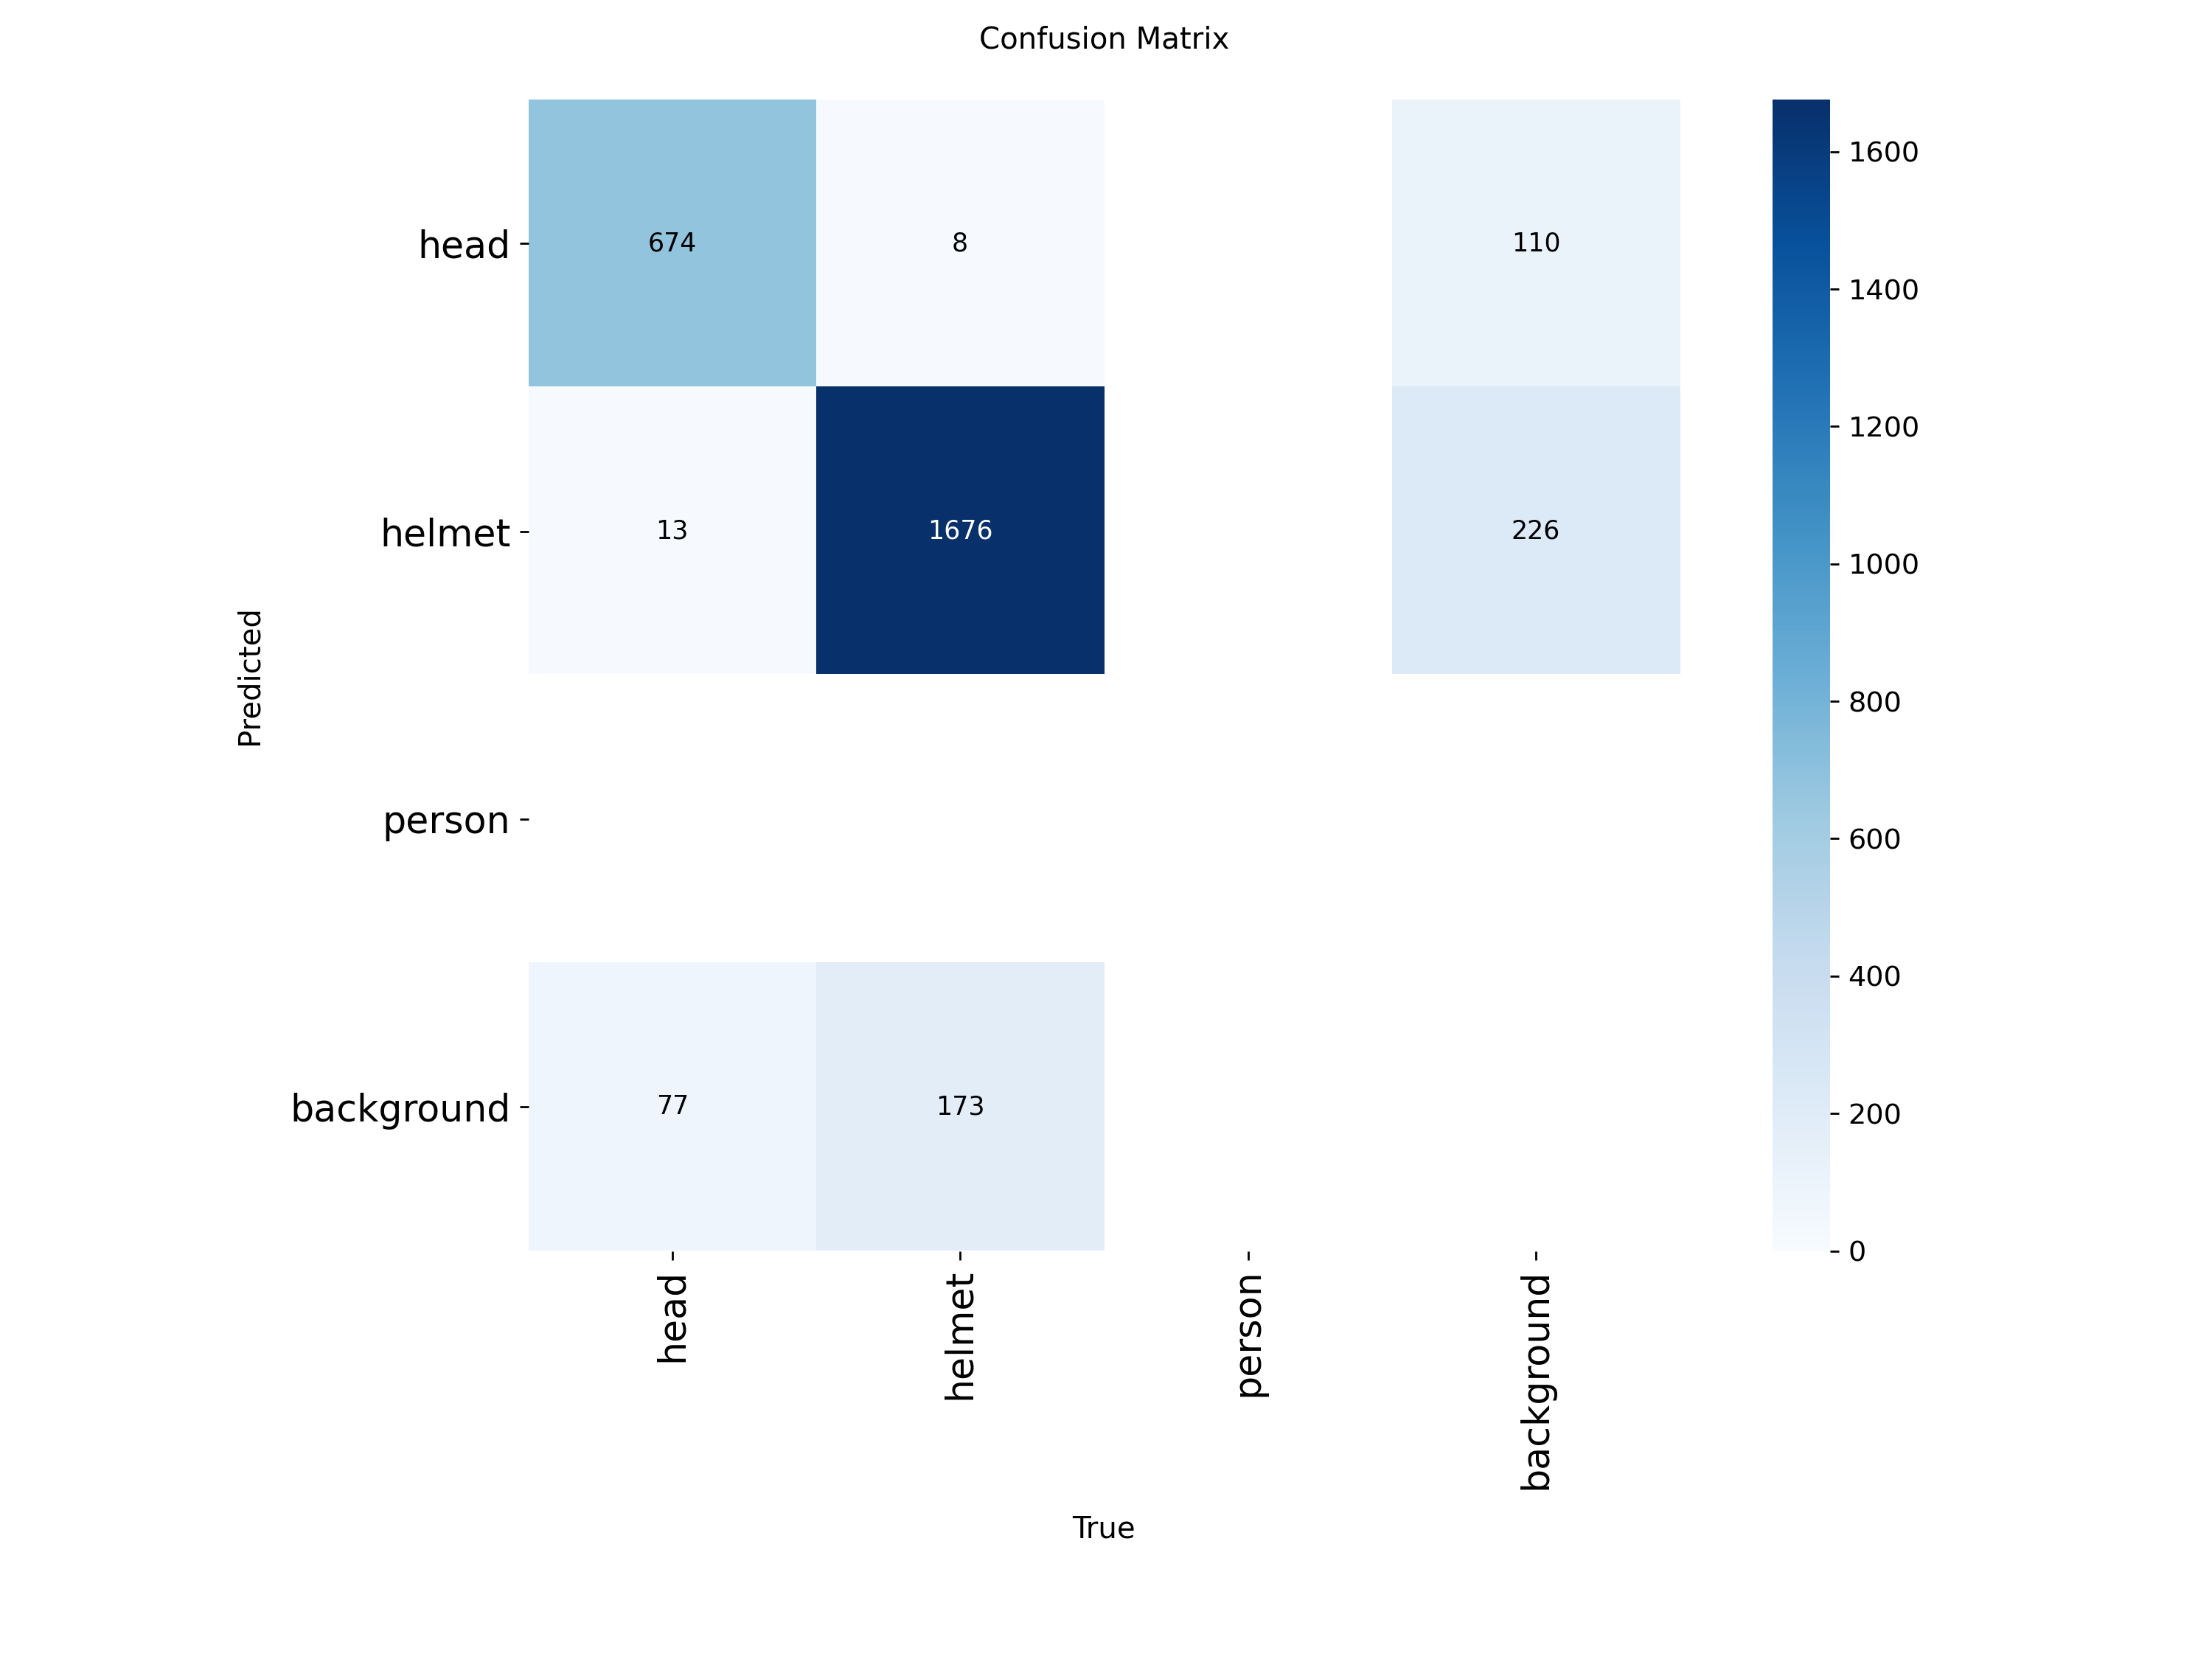

In [ ]:
path = '/content/evaluations/test_eval_v1/confusion_matrix.png'
display(Image(filename=path))

Model menunjukkan performa klasifikasi yang sangat kuat, terutama dalam membedakan antara objek head dan helmet. Model berhasil mengidentifikasi dengan benar 674 instansi untuk head dan 1676 instansi untuk helmet. Meskipun demikian, terdapat sedikit kebingungan (confusion) antara kedua kelas tersebut, di mana 13 instansi helmet salah diprediksi sebagai head, dan 8 instansi head salah diprediksi sebagai helmet.

Selain itu, model masih menghadapi tantangan dalam membedakan objek dari latar belakang (background). Hal ini terlihat dari adanya 77 kasus latar belakang yang keliru dianggap sebagai head dan 173 kasus latar belakang yang keliru dianggap sebagai helmet. Di sisi lain, terdapat pula false negative sebanyak 110 untuk head dan 226 untuk helmet yang justru diklasifikasikan sebagai latar belakang oleh model.

## Test Precision-Recall Curve

File ditemukan di: /content/evaluations/test_eval_v1/BoxPR_curve.png


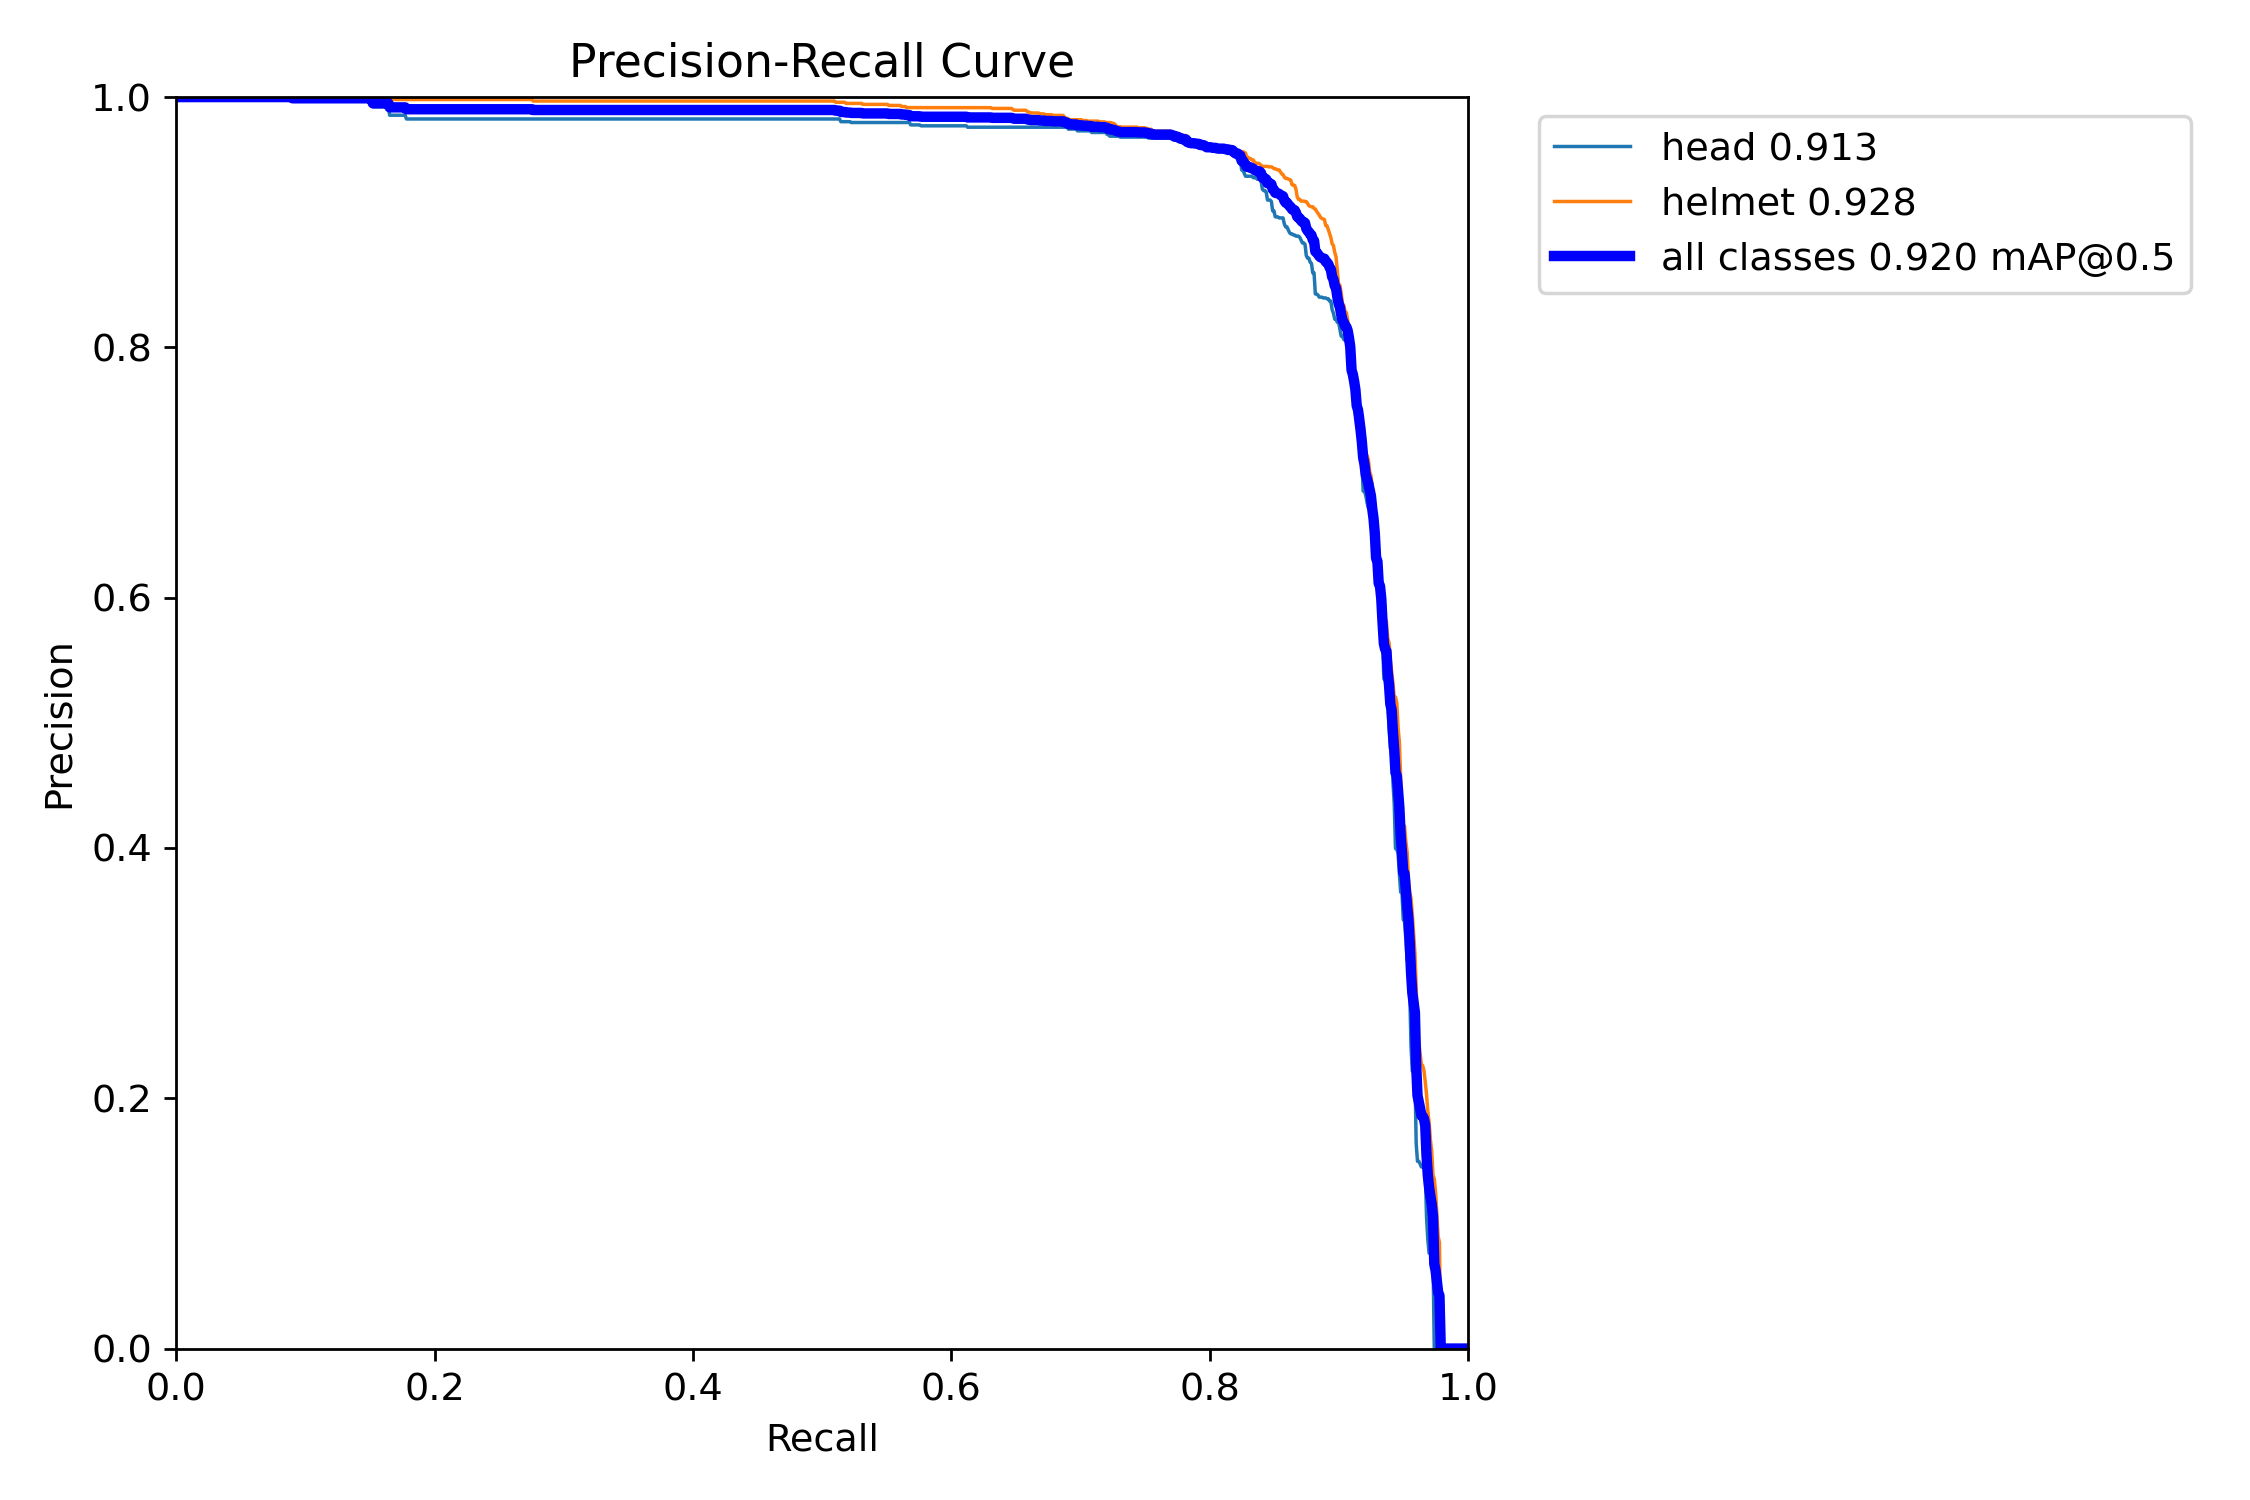

In [ ]:
import os
from IPython.display import Image, display

folder_path = '/content/evaluations/test_eval_v1'
file_name = 'BoxPR_curve.png'
full_path = os.path.join(folder_path, file_name)

if os.path.exists(full_path):
    print(f"File ditemukan di: {full_path}")
    display(Image(filename=full_path))
else:
    print(f"File {file_name} tidak ditemukan di {folder_path}")
    print("Isi folder yang tersedia:", os.listdir(folder_path) if os.path.exists(folder_path) else "Folder tidak ada")

Model menunjukkan performa yang sangat impresif dengan nilai mean Average Precision (mAP@0.5) untuk seluruh kelas mencapai 0,920. Kurva ini menggambarkan keseimbangan yang optimal antara precision (ketepatan) dan recall (cakupan) untuk kedua kelas yang dideteksi. Kelas "helmet" menunjukkan kinerja yang sedikit lebih unggul dengan nilai Average Precision sebesar 0,928 dibandingkan kelas "head" yang berada di angka 0,913. Secara keseluruhan, bentuk kurva yang tetap stabil pada tingkat presisi tinggi hingga recall mendekati 0,9 menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam memberikan prediksi yang akurat tanpa banyak mengalami kesalahan false positive sebelum akhirnya performanya menurun tajam.

## Test F1 Curve

File ditemukan di: /content/evaluations/test_eval_v1/BoxF1_curve.png


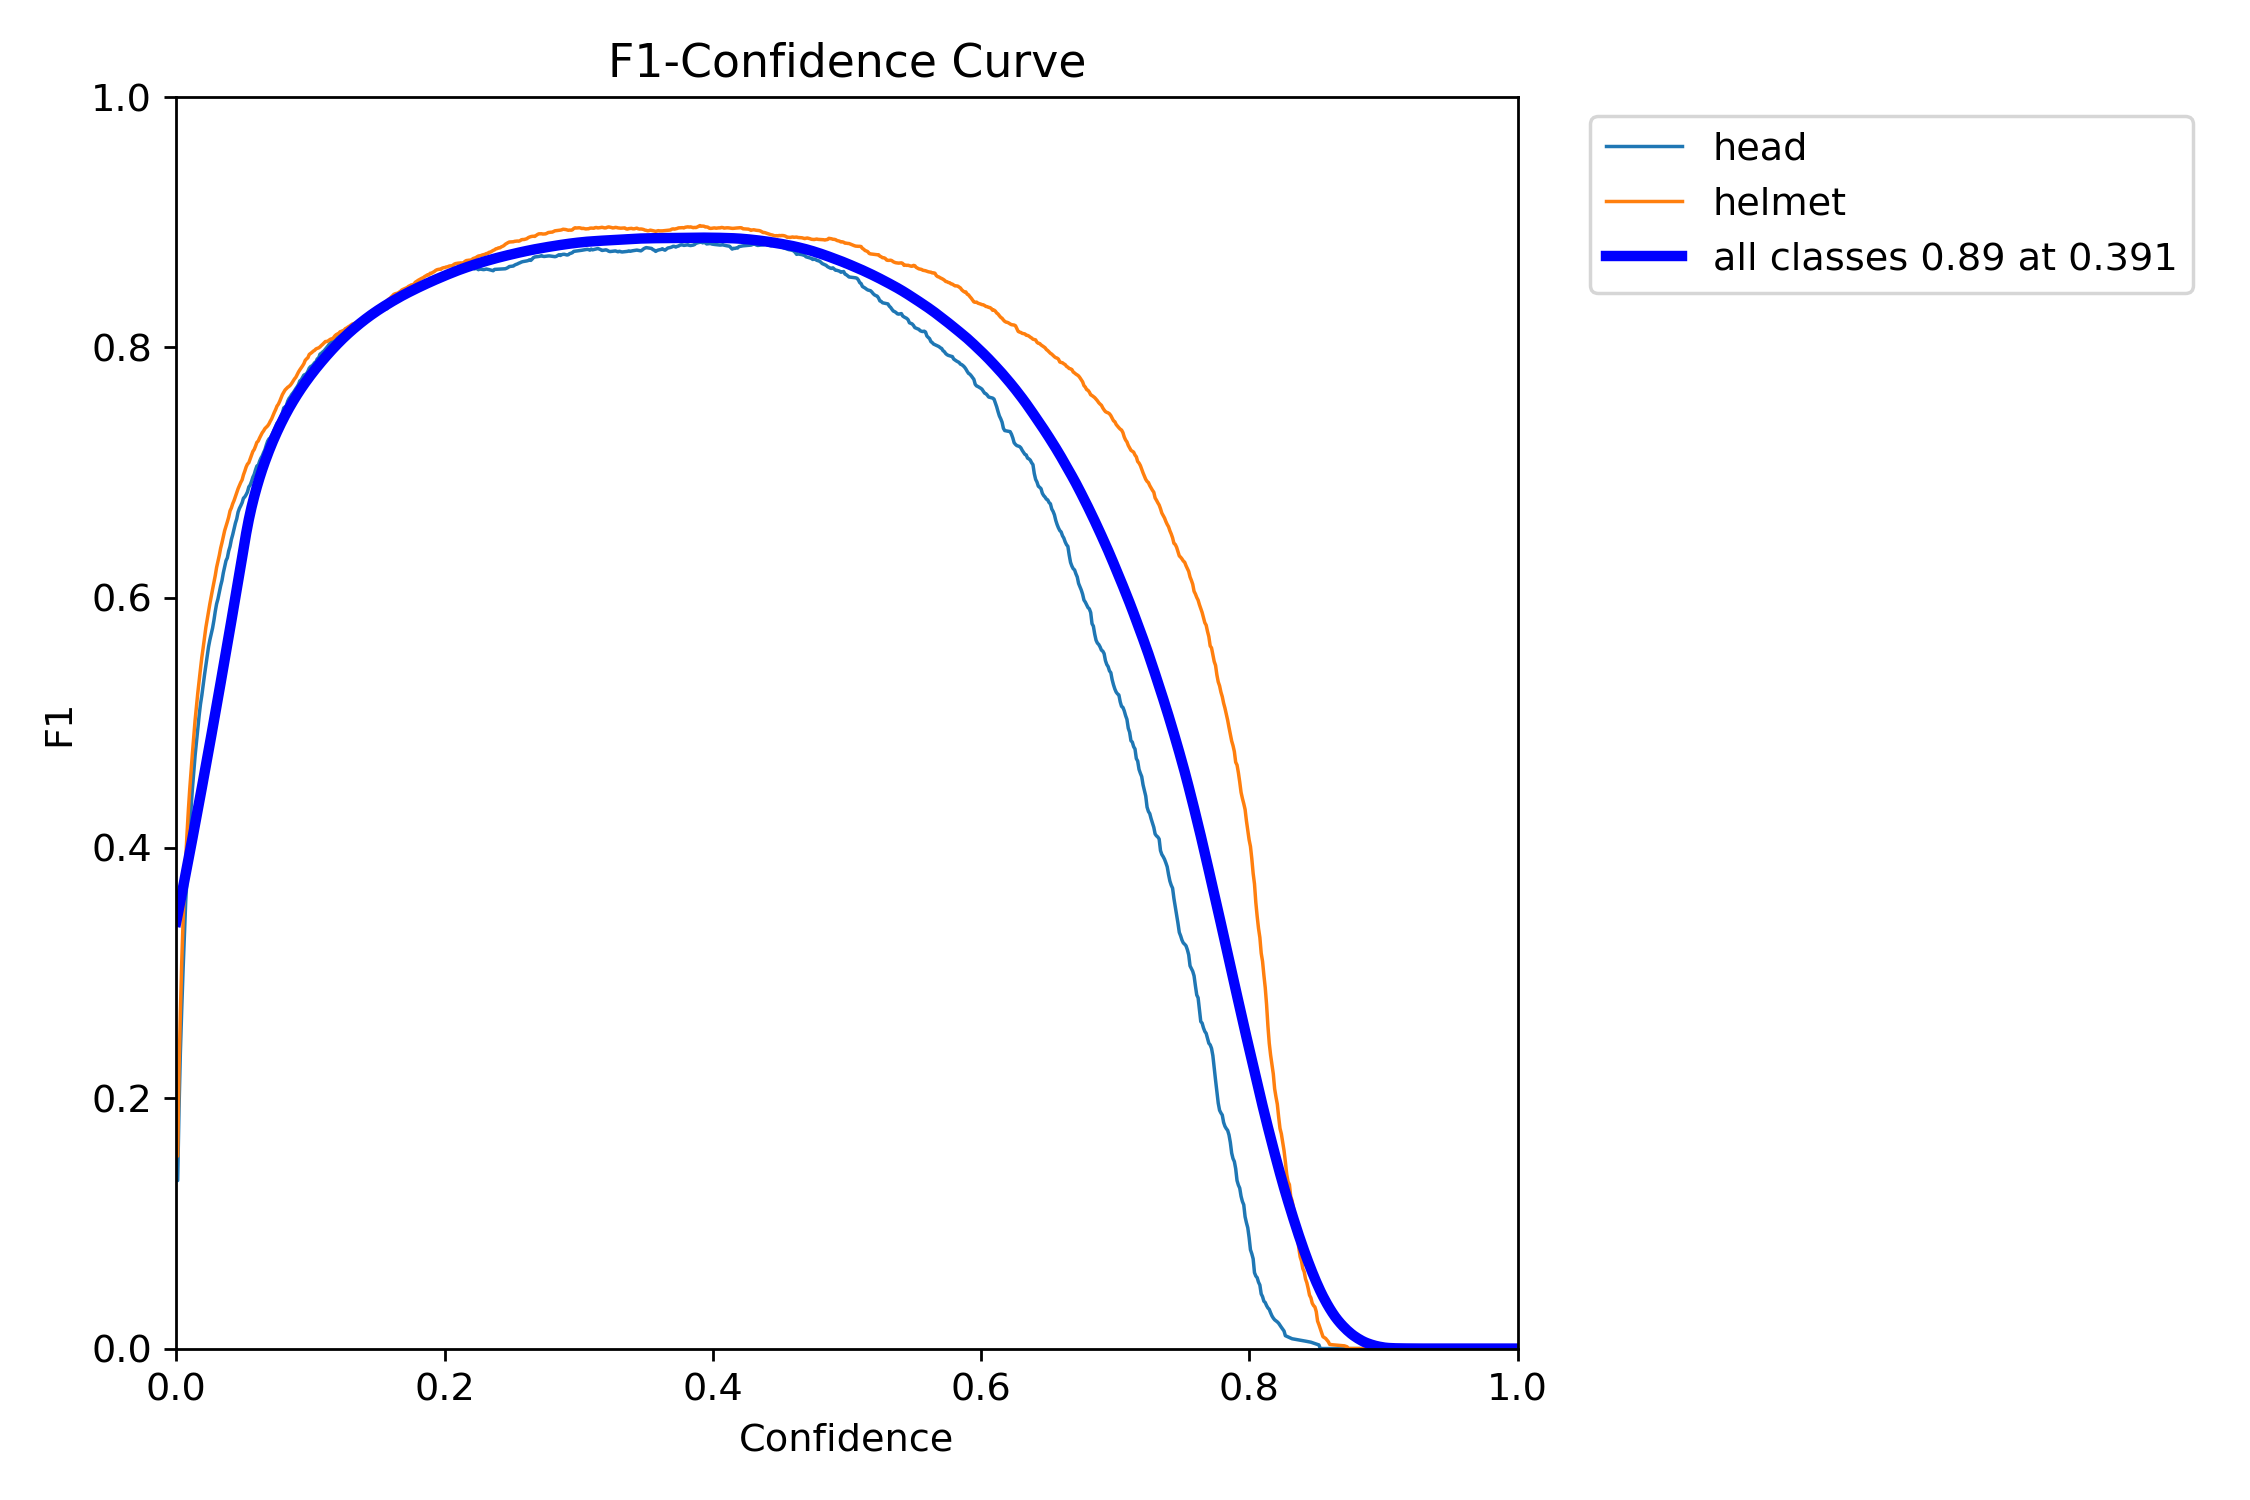

In [31]:
folder_path = '/content/evaluations/test_eval_v1'
file_name = 'BoxF1_curve.png'
full_path = os.path.join(folder_path, file_name)

# 2. Cek apakah filenya benar-benar ada
if os.path.exists(full_path):
    print(f"File ditemukan di: {full_path}")
    display(Image(filename=full_path))

# display(Image('/content/evaluations/test_eval_v1/BoxF1_curve.png'))

Kurva *F1-Confidence* menunjukkan keseimbangan optimal antara *precision* dan *recall* yang dicapai oleh model deteksi objek Anda. Secara keseluruhan, model mencapai nilai *F1-score* puncak sebesar 0,89 pada tingkat kepercayaan (*confidence threshold*) sebesar 0,391. Hal ini menunjukkan bahwa pada ambang batas tersebut, model berada pada titik performa paling efisien dalam mendeteksi objek secara akurat tanpa terlalu banyak mengalami *false positives* maupun *false negatives*. Kurva "helmet" konsisten berada di atas kurva "head", yang mengindikasikan bahwa model memiliki kemampuan yang lebih stabil dan kuat dalam menjaga keseimbangan presisi dan cakupan untuk kelas helm dibandingkan dengan kepala.



## Test Recall Curve

File ditemukan di: /content/evaluations/test_eval_v1/BoxR_curve.png


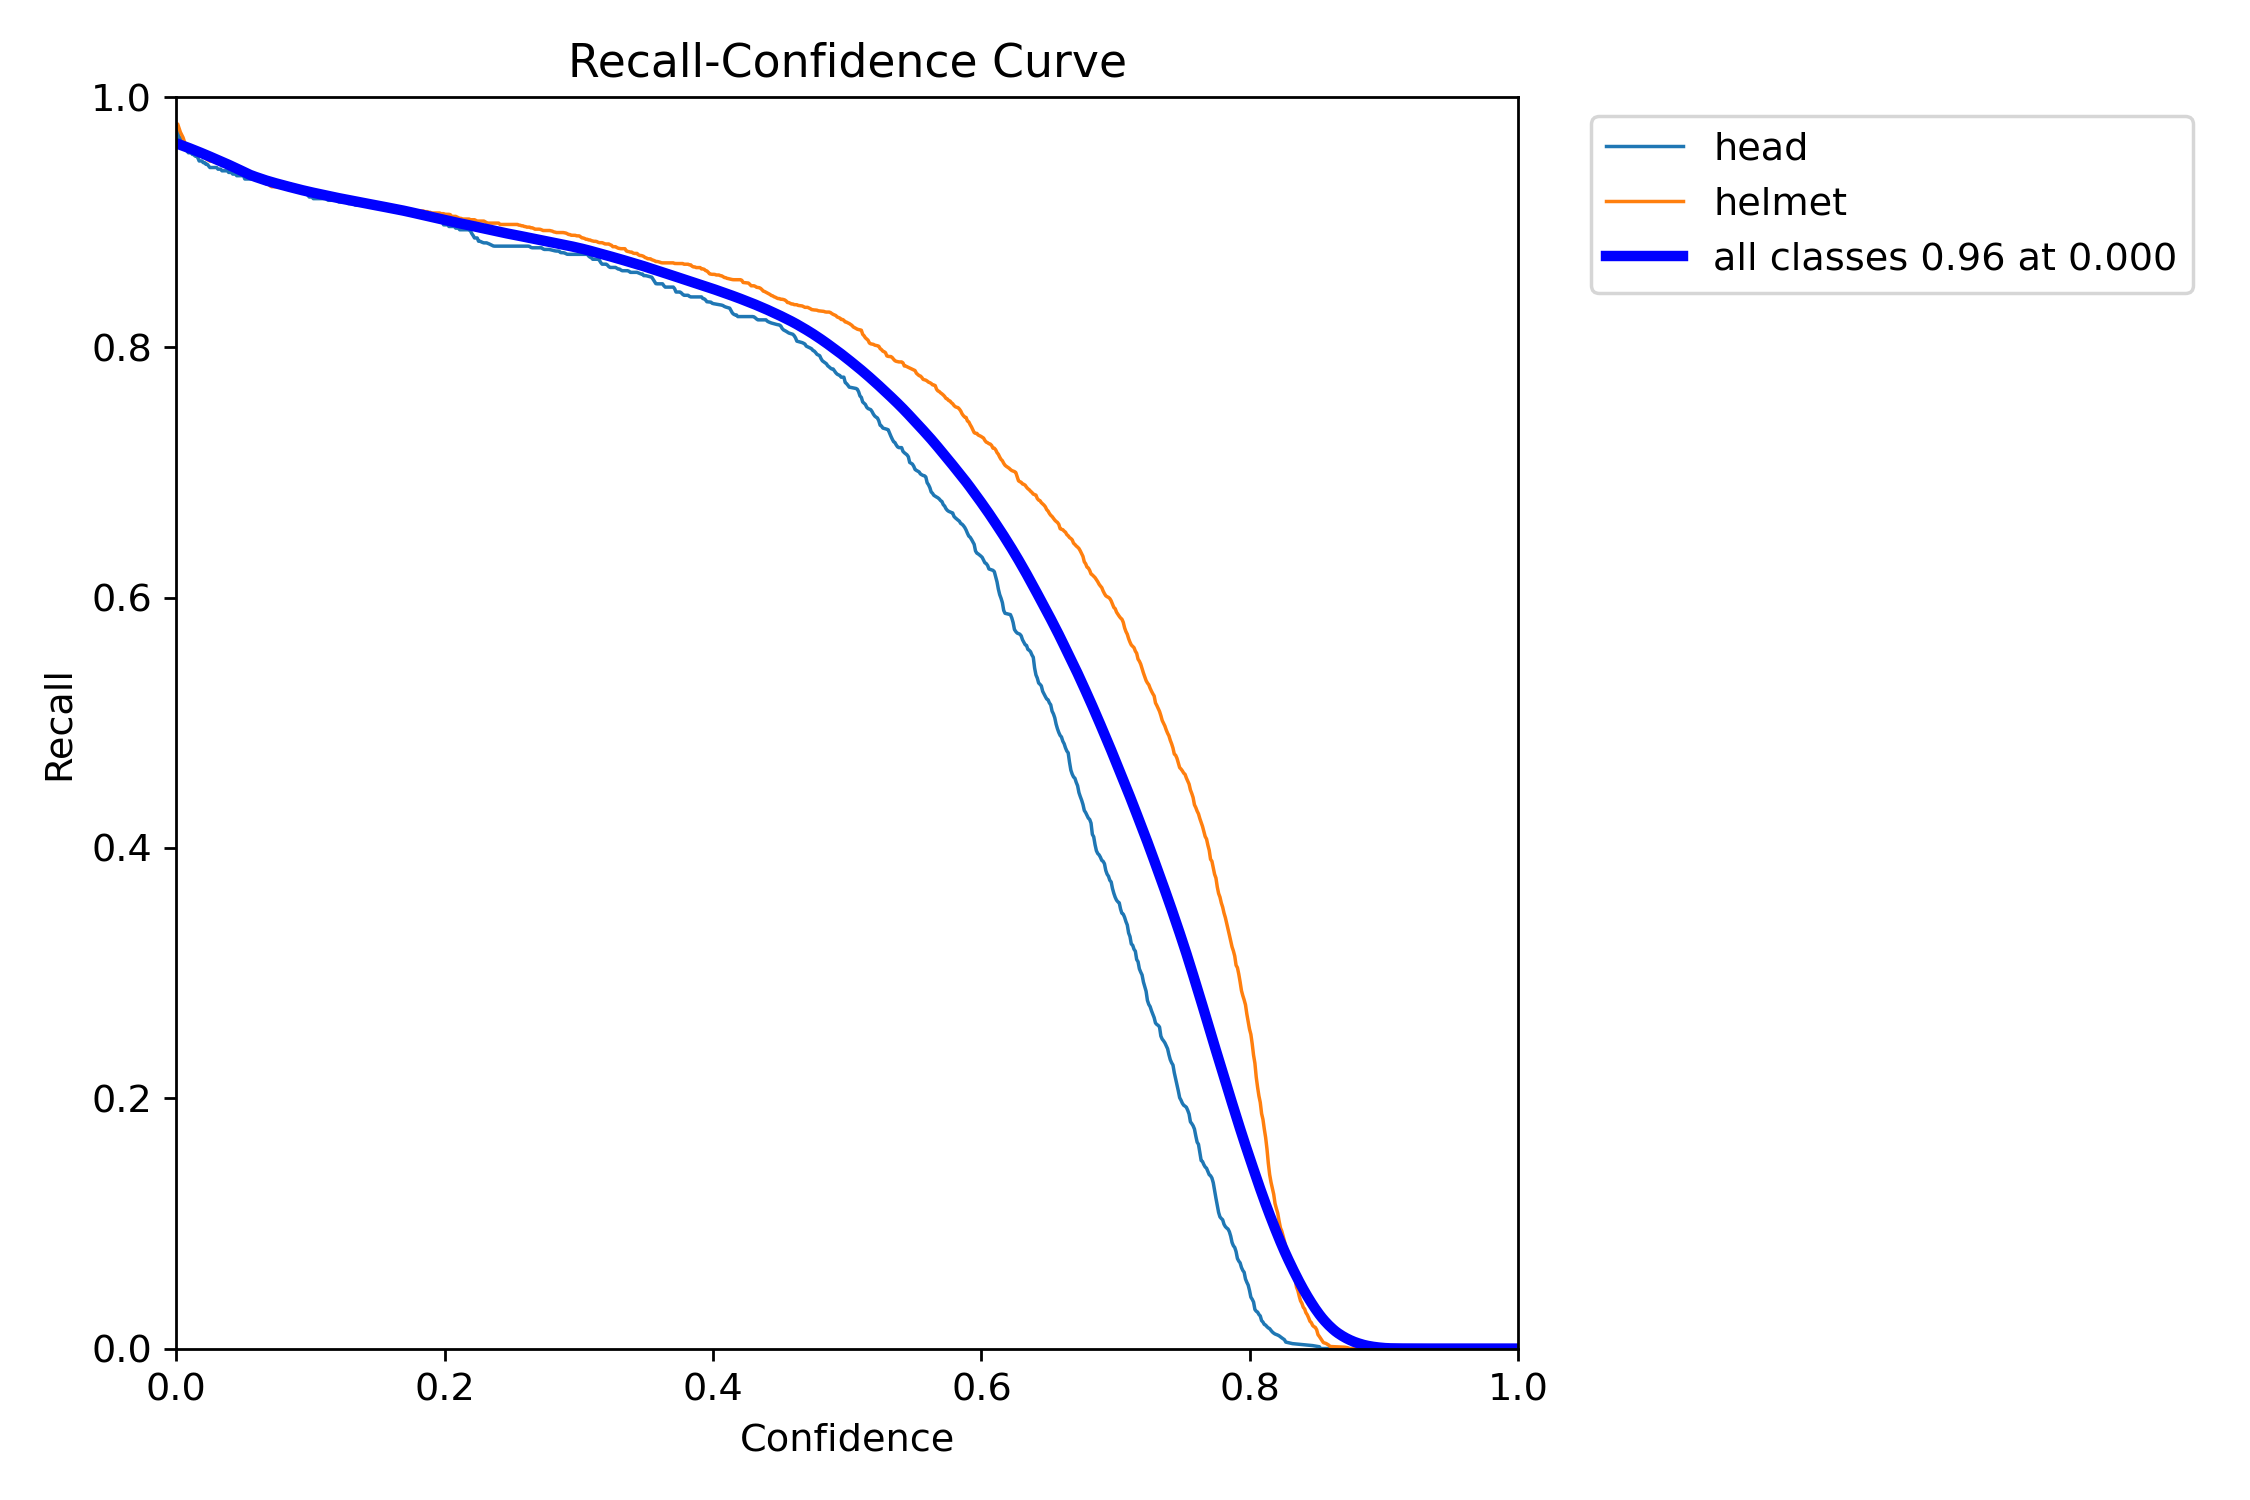

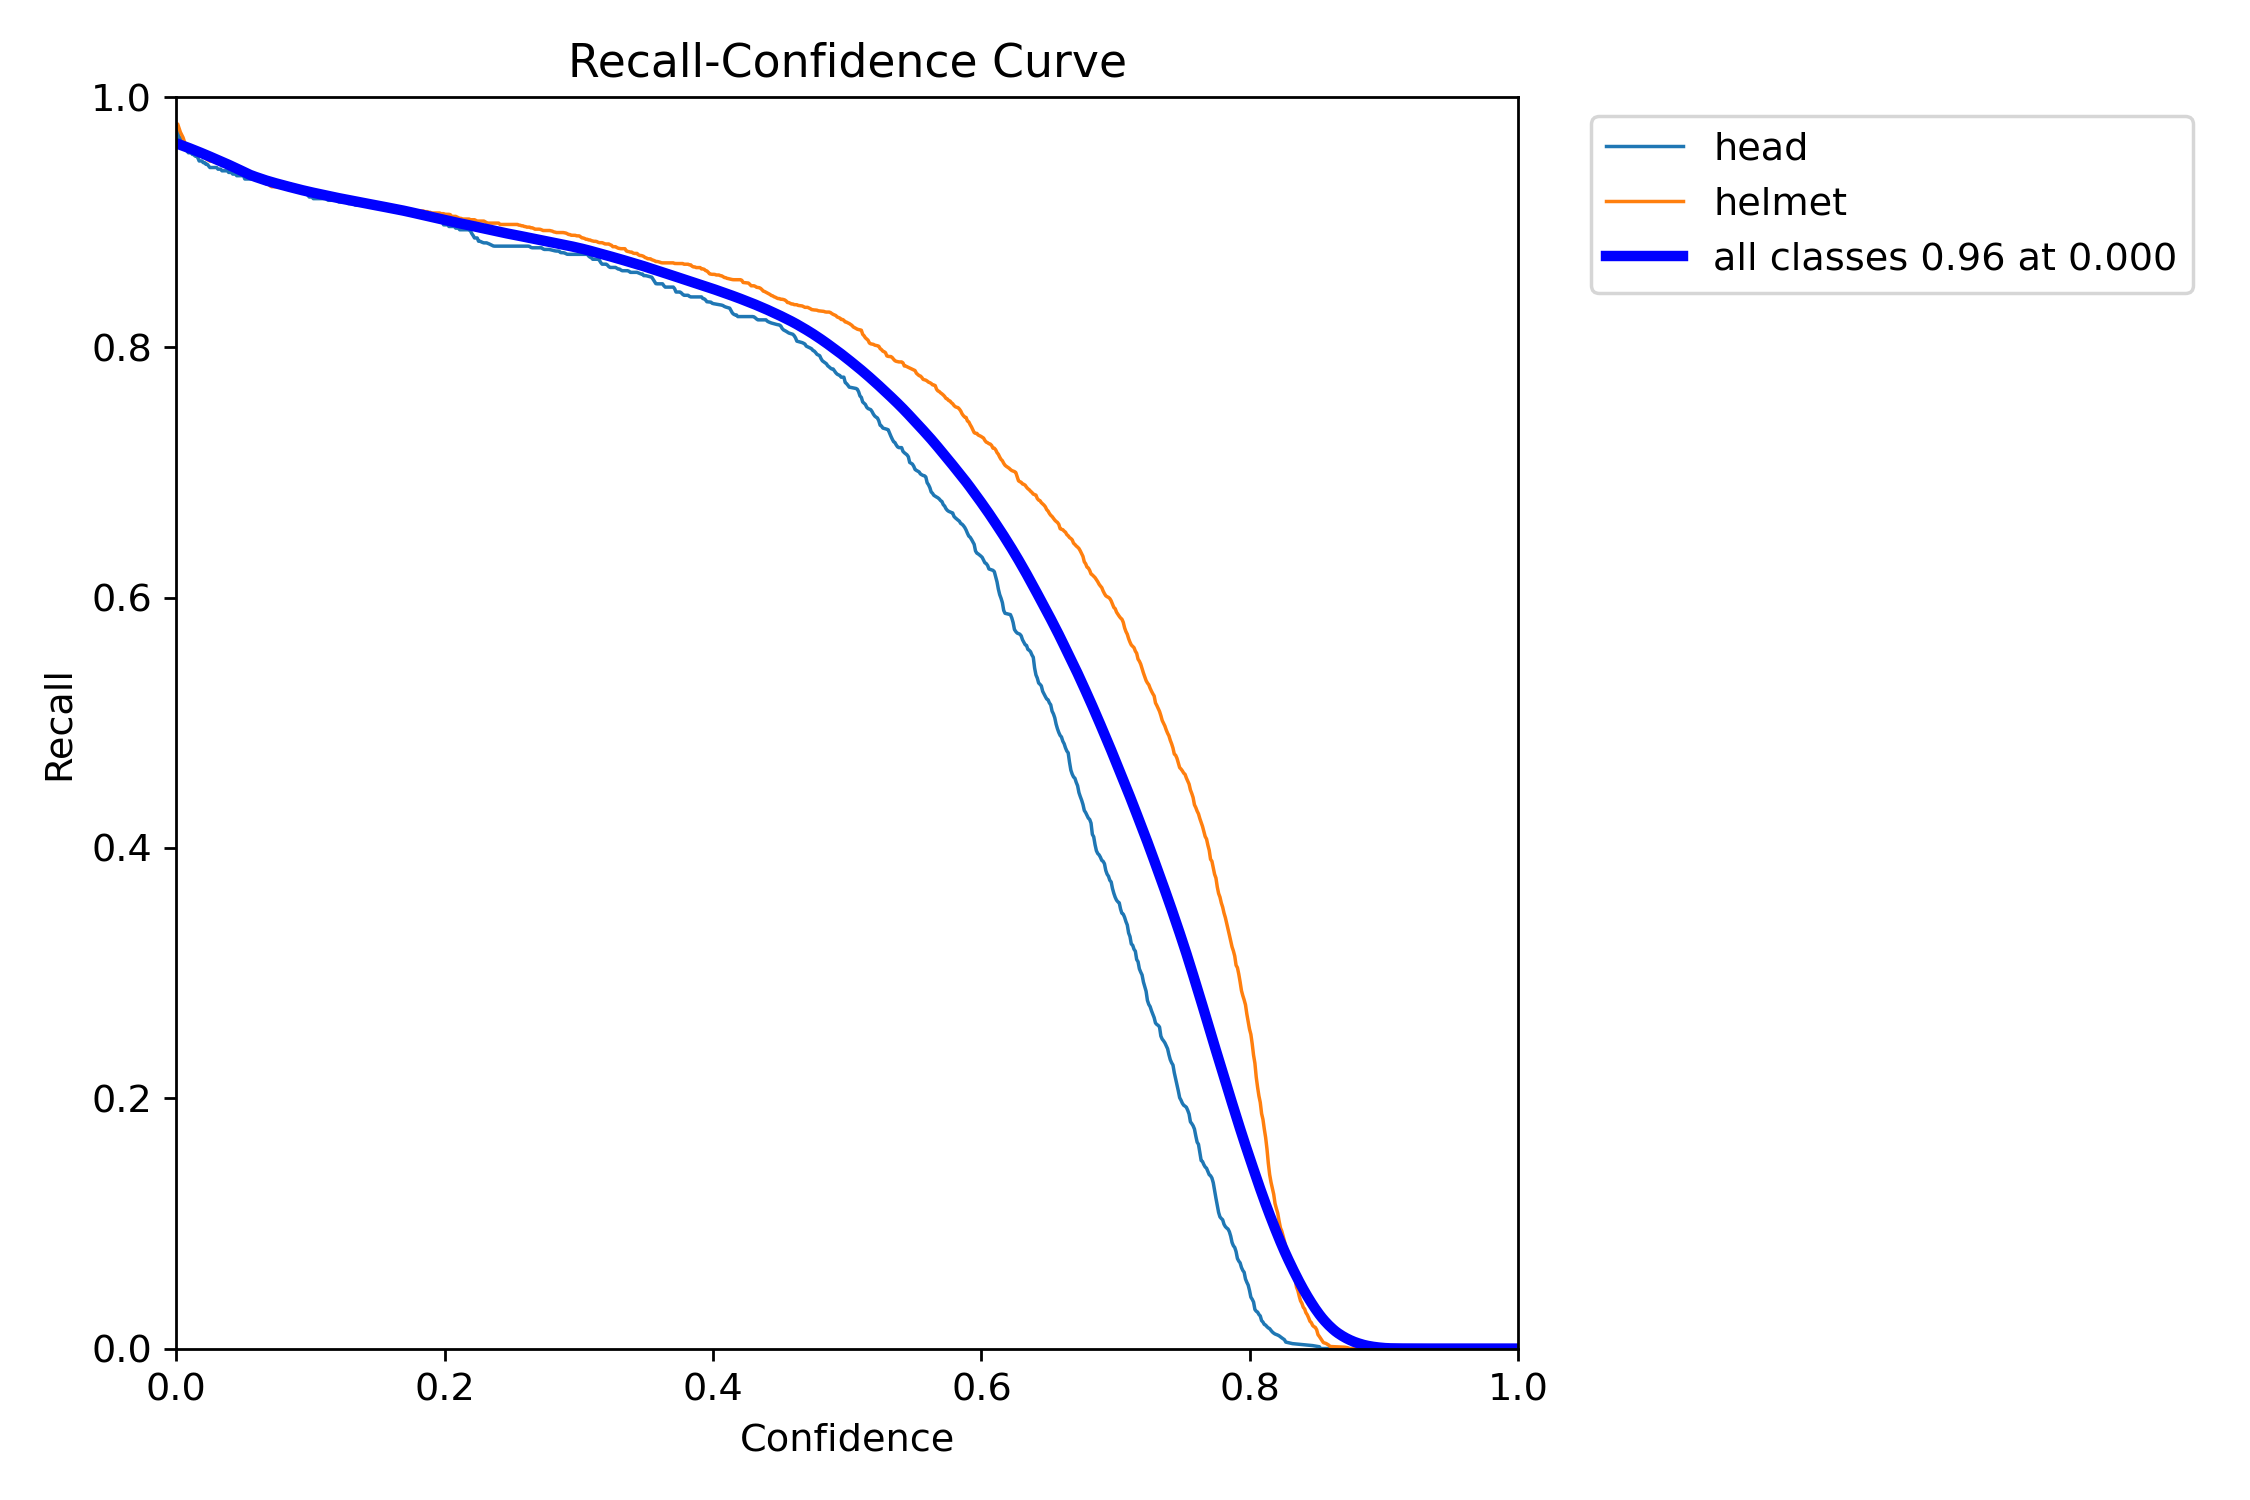

In [ ]:
folder_path = '/content/evaluations/test_eval_v1'
file_name = 'BoxR_curve.png'
full_path = os.path.join(folder_path, file_name)

if os.path.exists(full_path):
    print(f"File ditemukan di: {full_path}")
    display(Image(filename=full_path))

display(Image('/content/evaluations/test_eval_v1/BoxR_curve.png'))

Kemampuan model dalam mempertahankan cakupan deteksi objek (*recall*) seiring dengan perubahan ambang batas kepercayaan (*confidence threshold*). Secara keseluruhan, model mencapai performa *recall* sebesar 0,96 pada tingkat kepercayaan 0,000, yang menunjukkan sensitivitas tinggi dalam menangkap objek pada pengaturan awal. Kelas "helmet" secara konsisten menunjukkan performa yang lebih baik dibandingkan kelas "head" di seluruh rentang kurva. Meskipun model memiliki performa deteksi yang kuat, kurva ini menunjukkan penurunan *recall* yang lebih signifikan setelah ambang batas kepercayaan melampaui 0,6, yang mengindikasikan bahwa model menjadi lebih selektif dan mulai melewatkan beberapa instansi objek saat batasan kepercayaan diperketat.

## Sample Test Detection Results

Gunanya untuk melihat visualisasi hasil

In [33]:
results = model.predict(
    source='/content/Hard-Hat-Detection-1/test/images',
    save=True,
    conf=0.25
)


image 1/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1006_png.rf.256a979b0b85f9d8b2a68bd16af7e51b.jpg: 640x640 14 heads, 2 helmets, 21.6ms
image 2/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1018_png.rf.c50cb2c577064fbba7d47fb649da56ae.jpg: 640x640 4 helmets, 28.6ms
image 3/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1019_png.rf.9222efe332c6efb697531806a0c11125.jpg: 640x640 6 helmets, 20.6ms
image 4/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1020_png.rf.baa8a9818b49f4c547ed8ce1f30511cd.jpg: 640x640 8 helmets, 23.6ms
image 5/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1022_png.rf.9160c68da3e2854d01493902e1669fa0.jpg: 640x640 3 helmets, 32.3ms
image 6/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1023_png.rf.1628f4d867cfadb3564d456526e1ad7f.jpg: 640x640 7 helmets, 23.9ms
image 7/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1025_png.rf.65552c36a3a31e7638d84a10abf97d9

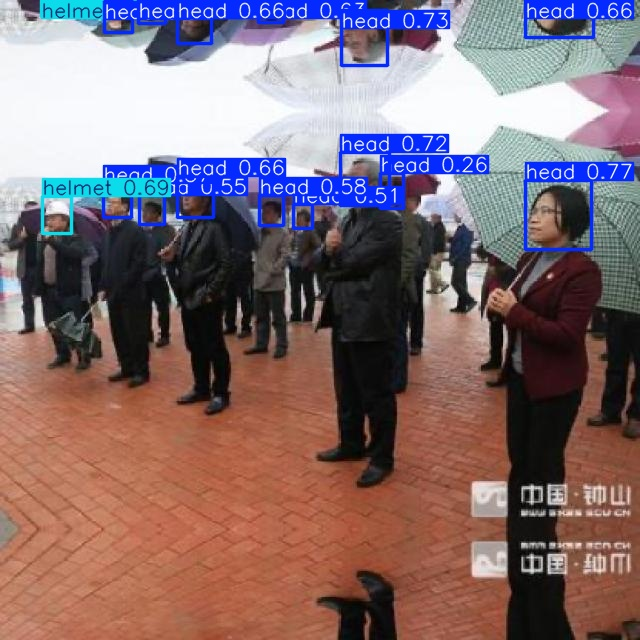

In [34]:
saved_image_path = os.path.join(results[0].save_dir, os.path.basename(results[0].path))
display(Image(saved_image_path))

Gambar hasil deteksi menunjukkan bahwa model mampu mengenali sebagian besar objek head dengan kuran baik, terlihat dari banyaknya bounding box berlabel head berada di antara 0.5-0.6. Model juga berhasil mendeteksi satu objek helmet dengan confidence sekitar 0.69. Dari sini, model hanya kurang yakin pada satu objek sehingga nilainya 0.26.



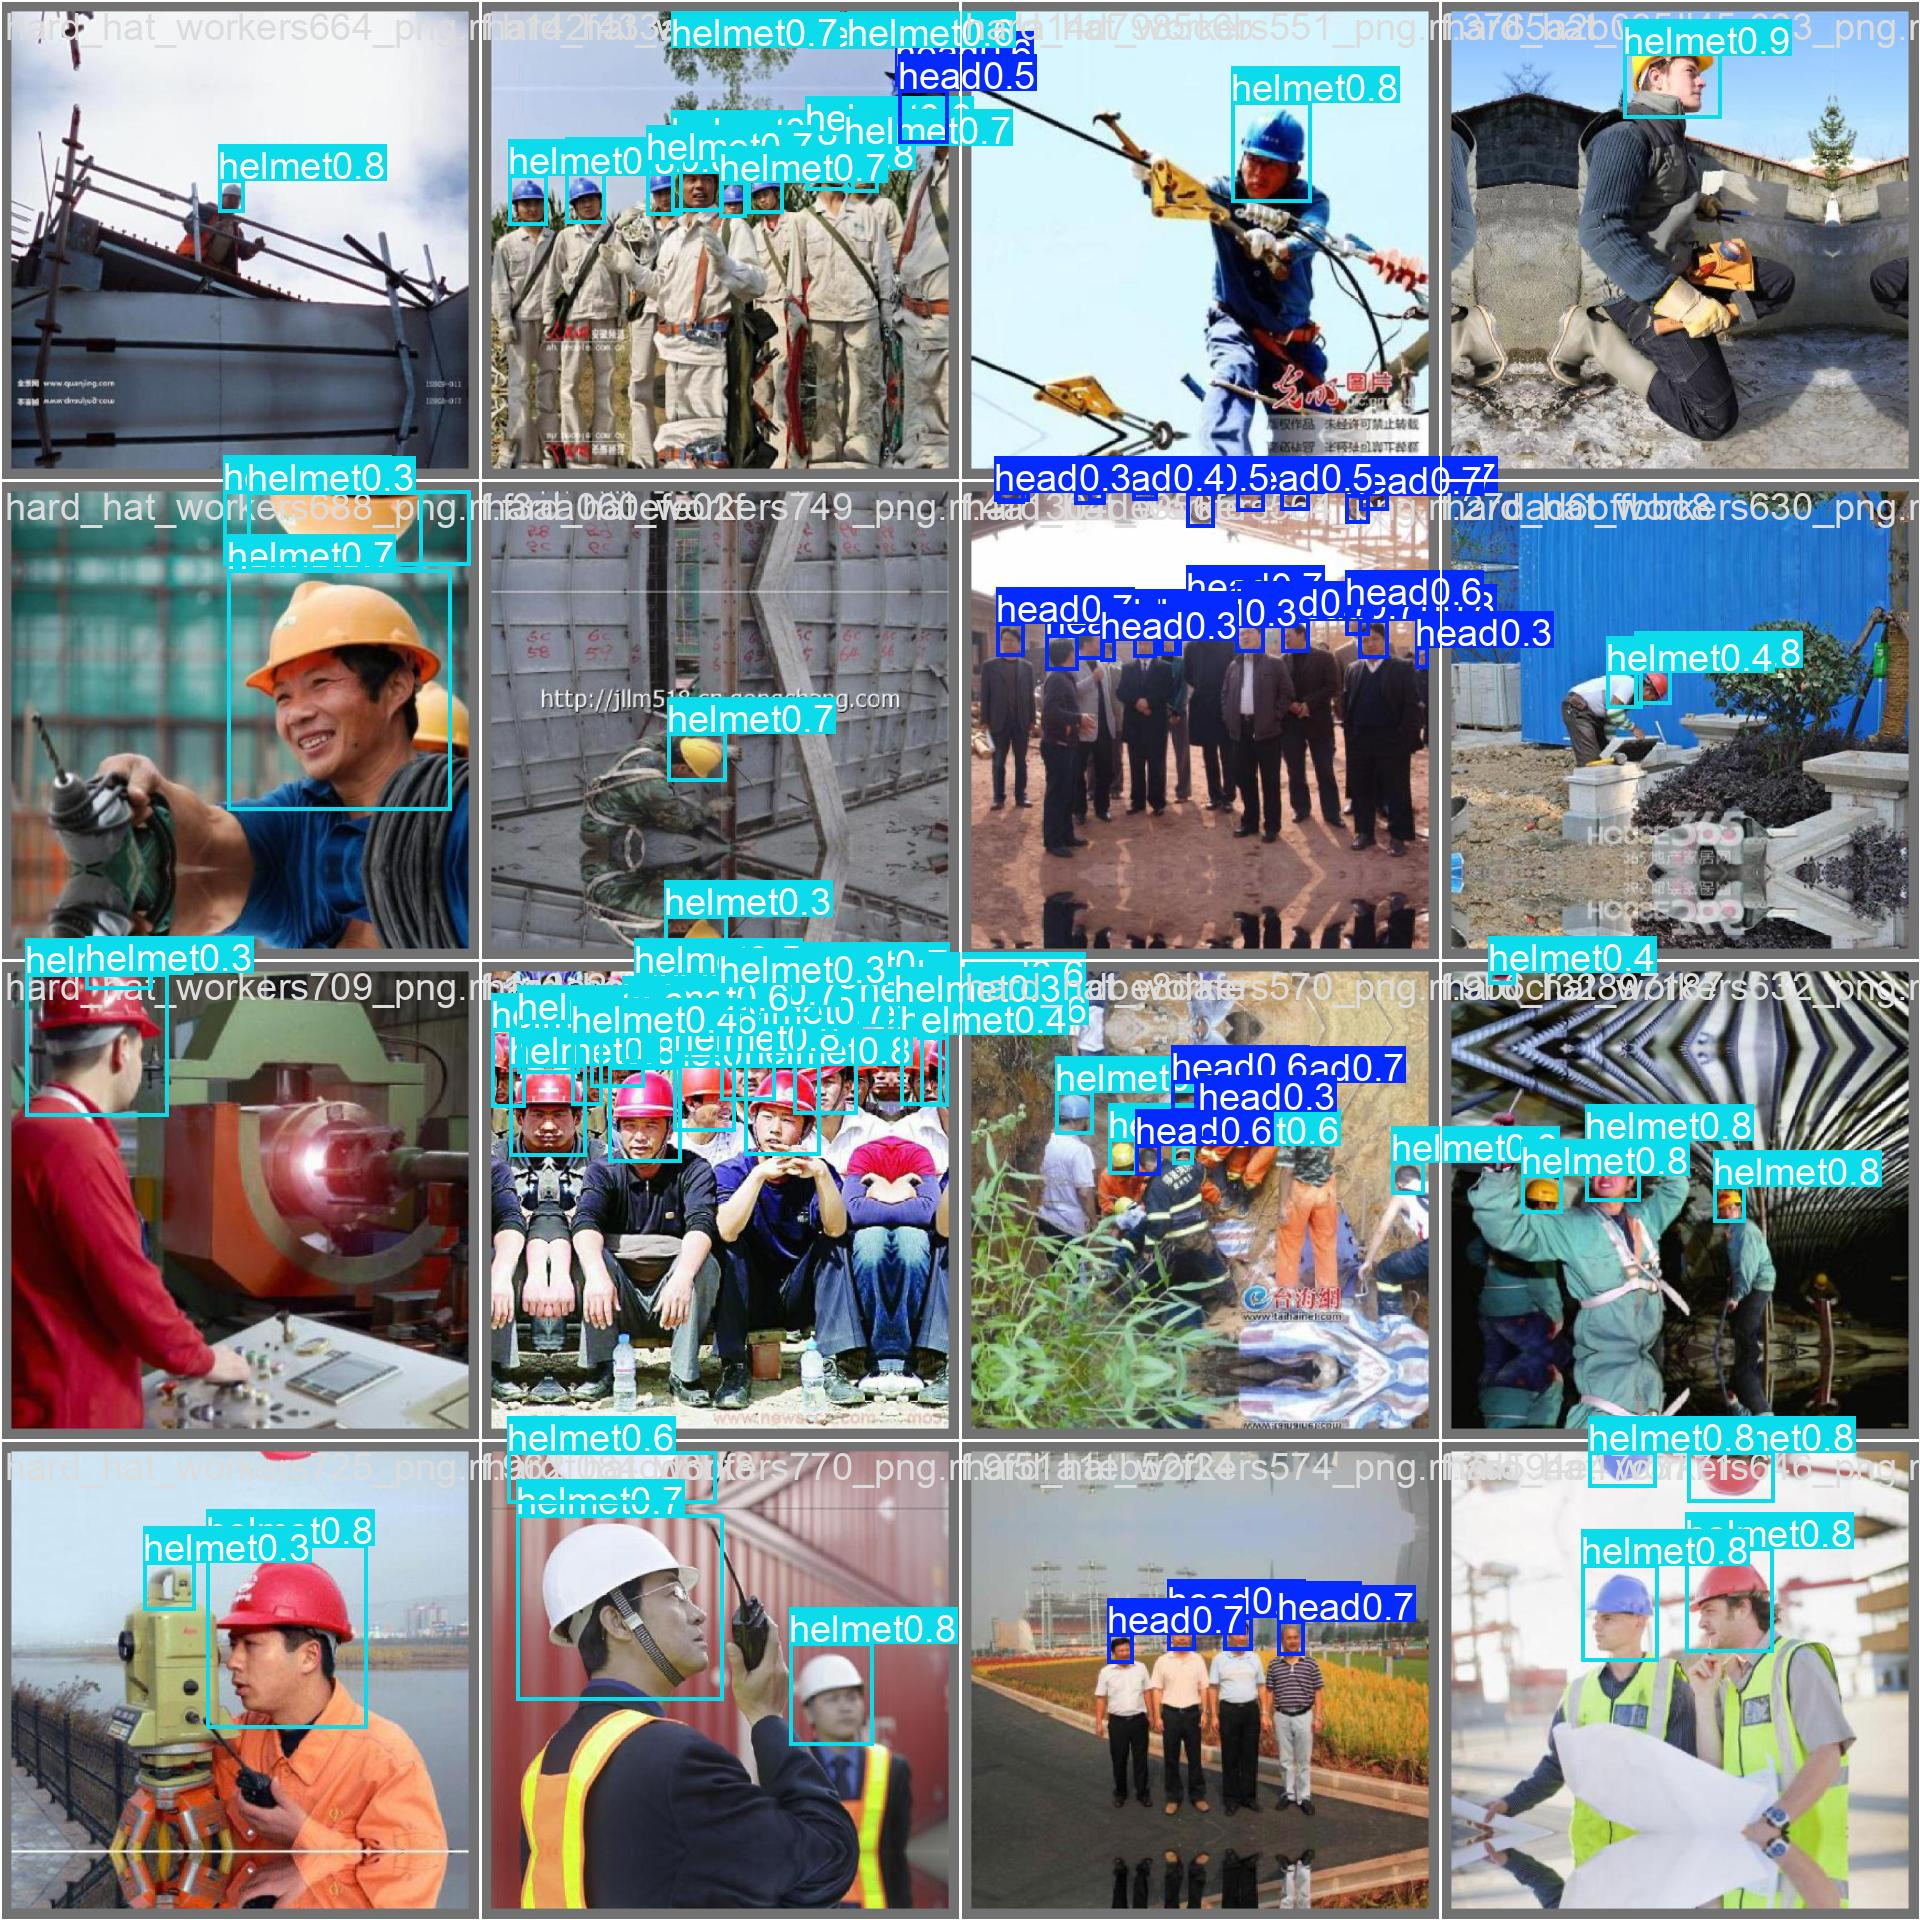

In [35]:
Image('/content/evaluations/test_eval_v1/val_batch0_pred.jpg')

Dari sini dapat terlihat bahwa masih terdapat condifence di angka 0.3.

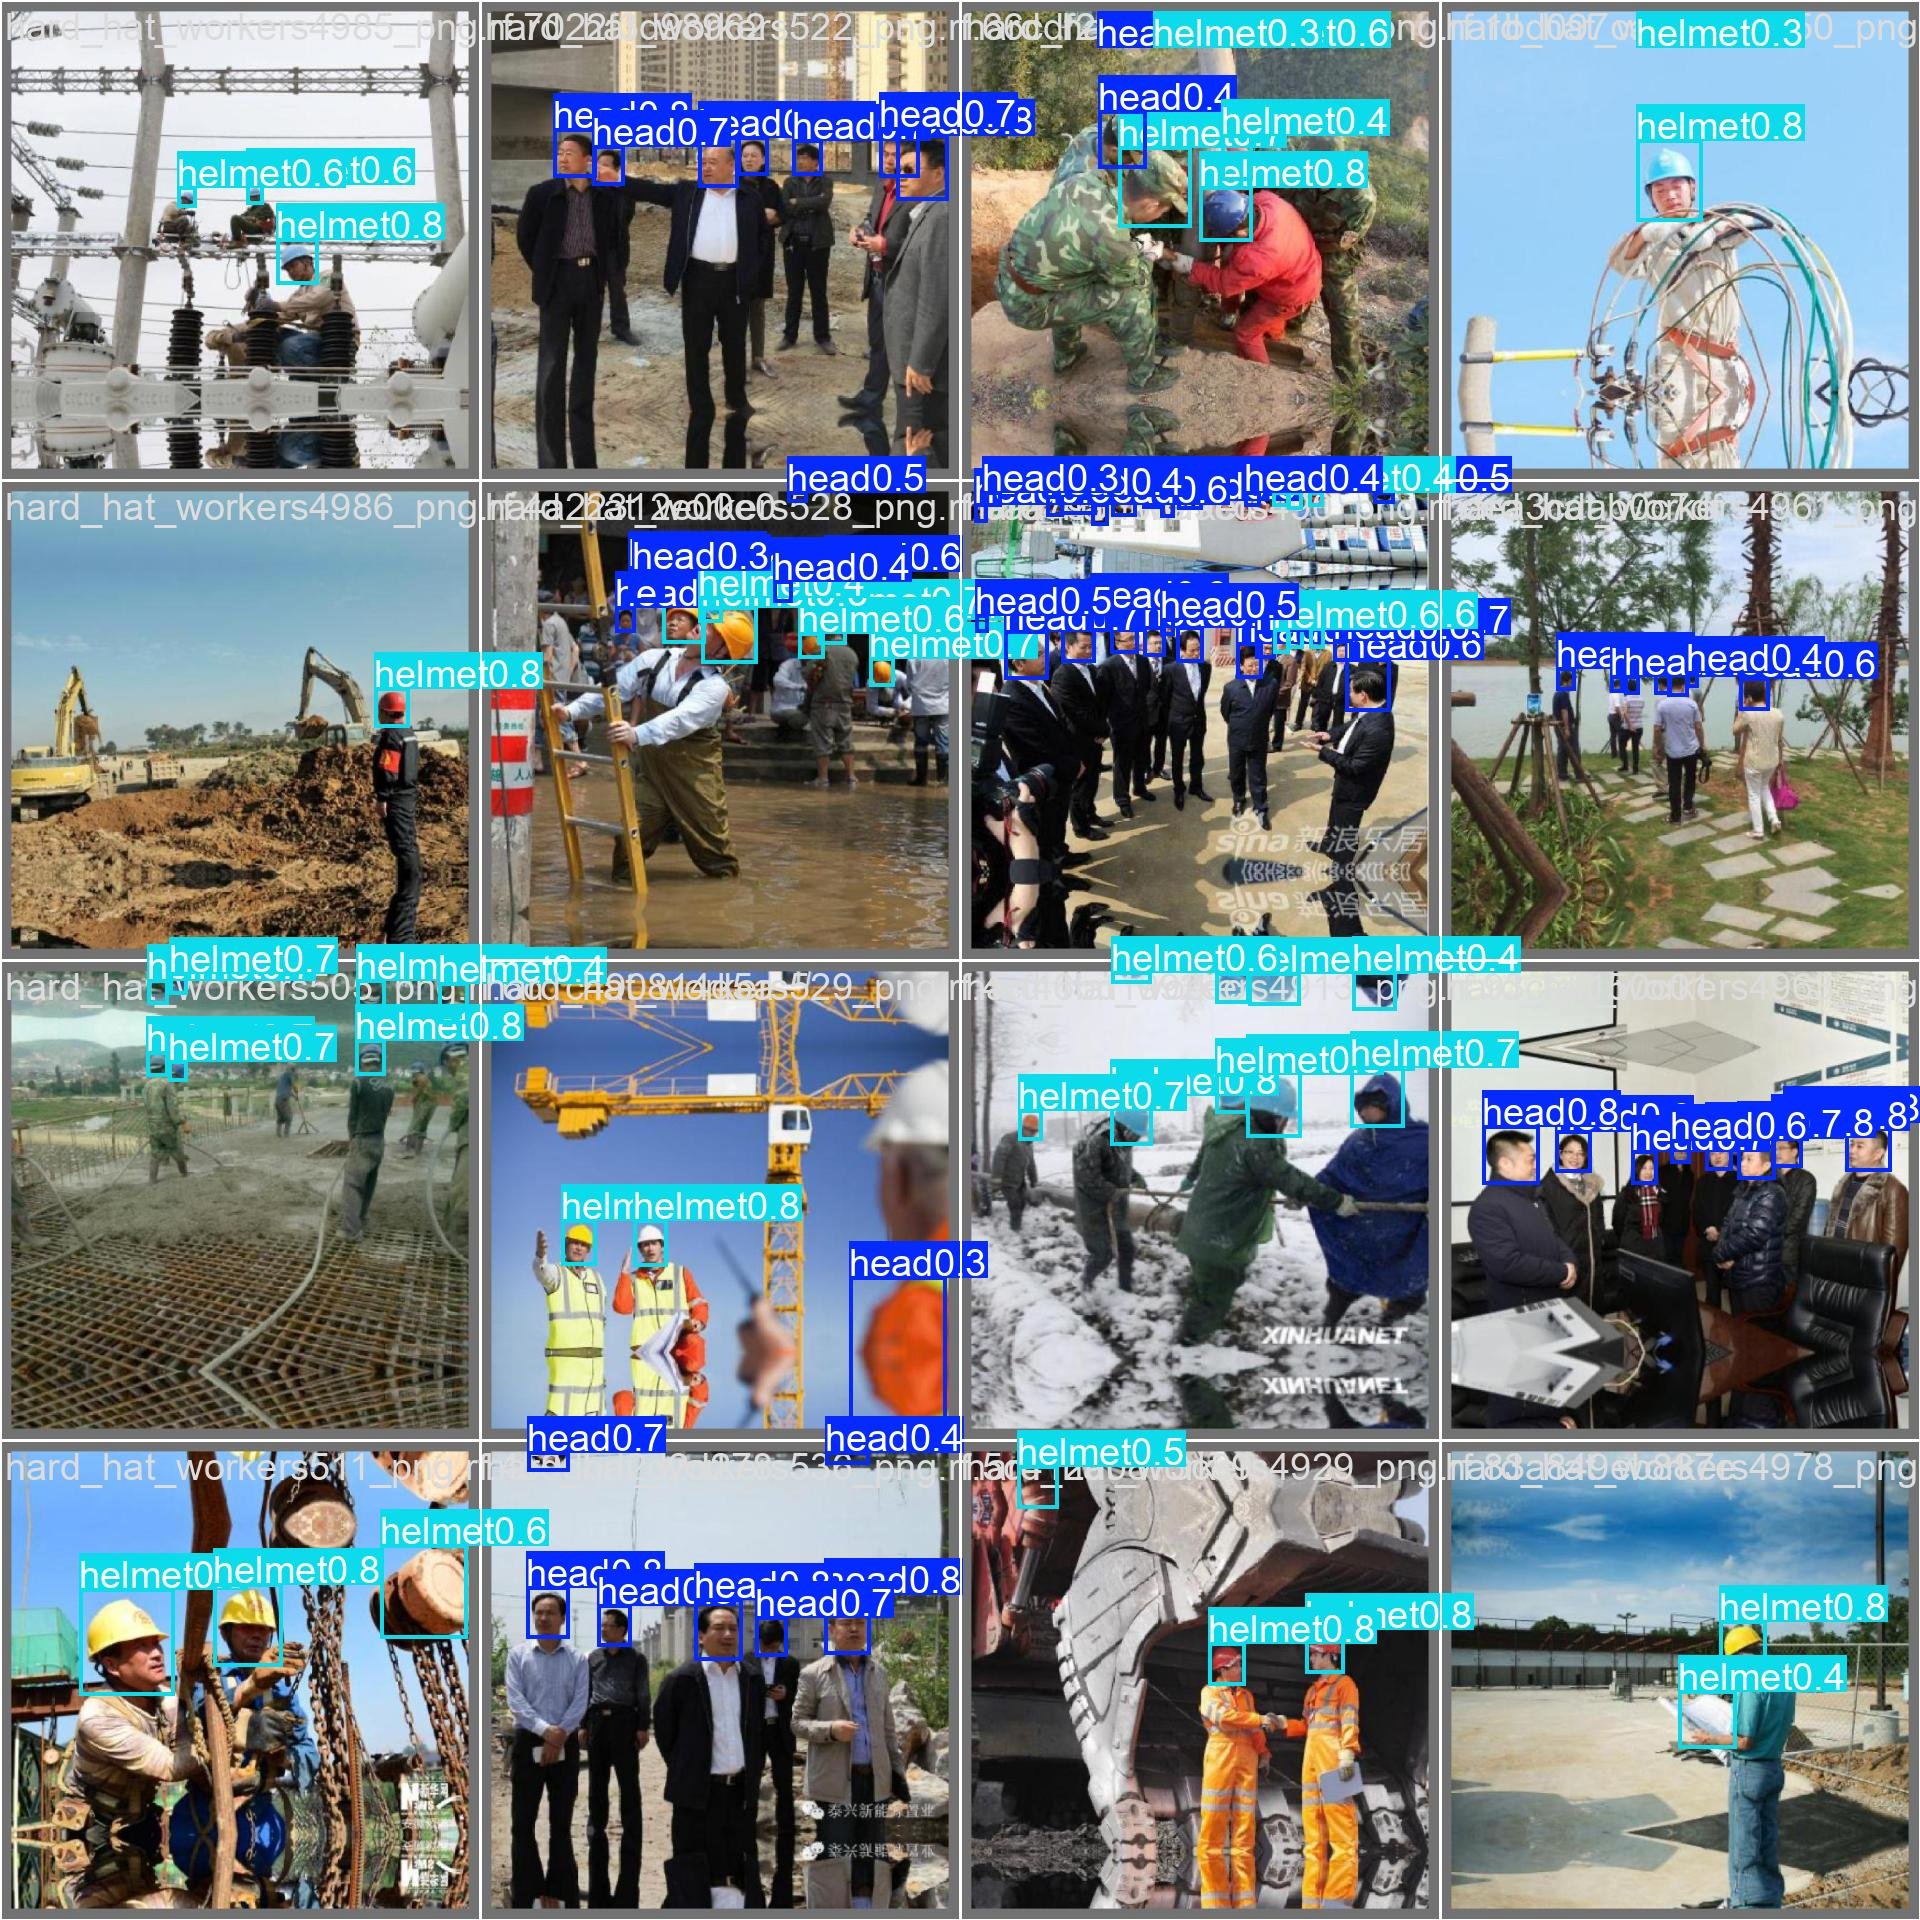

In [36]:
Image('/content/evaluations/test_eval_v1/val_batch1_pred.jpg')

Gambar ini menunjukkan bahwa model mampu mendeteksi kelas helmet dengan cukup baik pada berbagai kondisi lingkungan kerja. Sebagian besar objek helmet berhasil dikenali dengan nilai confidence yang cukup tinggi, umumnya berada pada kisaran 0.6 hingga 0.8, sehingga dapat dibilang bahwa model memiliki kemampuan yang stabil dalam memastikan keselamatan kerja. Selain itu, model juga dapat mendeteksi kelas head, namun pada beberapa gambar terlihat adanya bounding box yang saling bertumpuk serta label yang terlalu rapat. Pada beberapa kasus, model tampak mengalami kesulitan membedakan antara head dan helmet. Hal ini dapat dibuktikan dengan nilai rendah seperti 0.3- 0.4 ketika objek berukuran kecil, tertutup sebagian, terlalu banyak objek yang perlu dideteksi. Kelas person tidak terdeteksi sama sekali berarti model belum mampu mempelajari karakteristik kelas person secara optimal.

Secara keseluruhan dari ketiga gambar yang telah diberikan, dapat disimpulkan bahwa model deteksi objek sudah memiliki performa yang baik dalam mendeteksi kelas helmet dan kelas head, terutama pada objek yang terlihat jelas dan memiliki ukuran relatif besar. Model bisa bekerja pada berbagai kondisi gambar dan lingkungan dengan keakuratan yang cukup tinggi. Namun, masih terdapat beberapa kelemahan seperti munculnya overlap bounding box, duplicate detection, dan penempatan label yang bertumpuk sehingga hasil visualisasi menjadi kurang rapi. Selain itu, performa kelas person masih sangat rendah karena objek person sering tidak terdeteksi atau dianggap sebagai background dikarenakan  ketidakseimbangan dataset.


# Justification for Model
Pemilihan YOLOv12 sebagai model untuk deteksi helmet, head, dan person didasarkan pada berbagai peningkatan substansial dibandingkan iterasi sebelumnya. YOLOv12 menghadirkan mekanisme ekstraksi fitur yang lebih canggih, memungkinkan model untuk menangkap detail objek berukuran kecil serta tekstur helm dengan presisi yang jauh lebih tajam. Dalam skenario lapangan yang kompleks seperti keramaian di lokasi konstruksi, kondisi pencahayaan yang berubah-ubah, hingga objek yang saling tumpang tindih (occlusion). YOLOv12 menawarkan ketahanan deteksi yang lebih baik sehingga meminimalisir kesalahan klasifikasi latar belakang.
Selain keunggulan akurasi, YOLOv12 dirancang untuk mencapai efisiensi komputasi yang lebih optimal, memastikan inferensi real-time tetap stabil bahkan pada perangkat dengan spesifikasi terbatas. Dukungan untuk teknik augmentasi data yang lebih modern pada YOLOv12 memungkinkan proses training menjadi lebih fleksibel dan adaptif terhadap variasi data yang luas. Peningkatan kemampuan generalisasi ini memastikan bahwa model tidak hanya mahir pada data latihan, tetapi juga sangat andal saat diimplementasikan pada kondisi lingkungan kerja nyata yang dinamis, menjadikannya pilihan paling mutakhir untuk sistem pengawasan keselamatan kerja yang presisi dan responsif.

# Existing Challenges

* Munculnya beberapa kotak deteksi pada objek yang sama sehingga hasil prediksi menjadi kurang rapi dan dapat meningkatkan false positive.

* Model  mengalami kesulitan ketika objek berukuran kecil, tertutup Sebagian dan berada pada keramaian tinggi.

* Dataset yang tidaklah balanced menyebabkan klasifikasi kelas pada satu rendah sangatlah rendah.

# Future Opportunities

* Penambahan dataset terlebih untuk kelas person supaya model dapat mempelajari karakteristik objek manusia dengan lebih baik.

* Teknik augmentasi data yang lebih variative juga dapat membantu meningkatkan kemampuan generalisasi model pada berbagai kondisi lingkungan. Optimasi parameter seperti confidence threshold dan Non-Maximum Suppression (NMS) berpotensi mengurangi overlap serta duplicate detection.

* Training dengan waktu yang lebih lama seperti epoch 100 dengan patience 10 untuk mendapatkan hasil yang lebih baik.

* Penggunaan YOLO versi terbaru atau transformer-based detector untuk meningkatkan akurasi sekaligus efisiensi deteksi secara real-time.

* Berpeluang untuk diterapkan pada sistem keselamatan kerja otomatis dan pemantauan penggunaan helmet di area konstruksi sehingga keselematan pekerja akan lebih terjamin.



In [40]:
# Download file langsung dari Colab ke komputer lokal Anda
from google.colab import files
files.download('/content/drive/MyDrive/YoloV12SafetyHelmet/my_helmet_model/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>